## Agent Tooling Disclosure

This notebook was developed with the assistance of an AI agent (Claude, Anthropic) as a collaborative tool. The agent was used for:
- Scaffolding project structure and code templates
- Suggesting preprocessing pipelines and model configurations
- Generating visualisation code and report drafts
- Debugging errors and troubleshooting environment issues

**All agent outputs were critically reviewed, verified, and modified where necessary.** Key corrections include:
1. **Rejected** accuracy as a primary metric (agent initially suggested it alongside AUC-ROC — inappropriate for imbalanced data)
2. **Corrected** data leakage: agent initially applied StandardScaler before train-test split; corrected to fit on training data only
3. **Corrected** SMOTE application: agent initially suggested applying SMOTE before the split; corrected to training data only
4. **Modified** hyperparameter tuning: switched from automated RandomizedSearchCV to manual tuning due to computational constraints

A detailed Agent Usage Log and Decision Register is provided in the submission appendix.

In [1]:
# ============================================================
# SET WORKING DIRECTORY
# ============================================================
import os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
print(f"Working directory: {os.getcwd()}")


Working directory: /Users/anjaliyadav/Desktop/ml4b-assignment/Diabetes-prediction-analytics


# Diabetes Hospital Readmission Prediction
## MSIN0097 Predictive Analytics | MSc Business Analytics | UCL School of Management

**Problem:** Predict whether a diabetic patient will be readmitted to hospital within 30 days of discharge.

**Dataset:** [Diabetes 130-US Hospitals (1999-2008)](https://archive.ics.uci.edu/dataset/296) — 101,766 encounters × 50 features

**Clinical Significance:** Hospital readmissions cost the US healthcare system billions annually. Predicting readmission risk enables targeted interventions and improved patient outcomes.

---


In [2]:
# ============================================================
# IMPORTS & CONFIGURATION
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
sns.set_palette('colorblind')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("All imports successful")


All imports successful


---
# Step 1: Problem Framing

## 1.1 Problem Definition
**Objective:** Build a binary classifier to predict whether a diabetic patient will be readmitted to hospital within 30 days of discharge, using clinical encounter data from 130 US hospitals.

**Why it matters:** Hospital readmissions are a major quality-of-care indicator. The Hospital Readmissions Reduction Program (HRRP) penalises hospitals with excess readmissions. Early identification of high-risk patients enables targeted discharge planning and follow-up care.

## 1.2 Target Variable
- **Original target:** `readmitted` has 3 values: "<30" (within 30 days), ">30" (after 30 days), "NO"
- **We convert to binary:** 1 = readmitted within 30 days ("<30"), 0 = not readmitted within 30 days (">30" or "NO")

## 1.3 Success Metrics
| Metric | Rationale |
|--------|-----------|
| **AUC-ROC** (primary) | Robust to class imbalance; evaluates discrimination across thresholds |
| **F1-Score** (positive class) | Balances precision and recall for the minority readmission class |
| **Precision-Recall AUC** | More informative than ROC for imbalanced data |
| **Recall** | Clinically important — minimising missed readmission cases |

We avoid accuracy as the primary metric due to expected class imbalance.

## 1.4 Constraints
- **Interpretability:** Clinical stakeholders need explainable predictions
- **Cost asymmetry:** Missing a high-risk patient (false negative) is costlier than a false alarm
- **Data limitations:** Retrospective data, unknown selection biases, age grouped in ranges

## 1.5 Agent Tooling Plan
| Task | Delegate to Agent | Verify Myself |
|------|-------------------|---------------|
| Scaffold project structure | Yes | Review structure |
| Suggest metrics | Yes | Validate for imbalanced classification |
| Generate EDA code | Yes | Check all plots and interpretations |
| Build preprocessing pipeline | Yes | Verify no data leakage |
| Suggest models | Yes | Validate via experiments |


In [3]:
# ============================================================
# 1.6 LOAD THE RAW DATASET
# ============================================================
df_raw = pd.read_csv('data/diabetic_data.csv')

print(f"Raw dataset shape: {df_raw.shape}")
print(f"Rows: {df_raw.shape[0]:,}")
print(f"Columns: {df_raw.shape[1]}")
print(f"\nColumn names:")
print(list(df_raw.columns))
df_raw.head()


Raw dataset shape: (101766, 50)
Rows: 101,766
Columns: 50

Column names:
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [4]:
# ============================================================
# 1.7 INITIAL DATA QUALITY CHECK (BEFORE CLEANING)
# ============================================================
print("DATA TYPES:")
print("="*60)
print(df_raw.dtypes)
print(f"\nMemory usage: {df_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB")

# Check for '?' missing values
print(f"\n{'='*60}")
print("COLUMNS WITH '?' MISSING VALUES (before cleaning):")
print("="*60)
missing_q = (df_raw == '?').sum()
missing_q = missing_q[missing_q > 0].sort_values(ascending=False)
for col, count in missing_q.items():
    print(f"  {col}: {count:,} ({count/len(df_raw)*100:.1f}%)")

print(f"\nOriginal target distribution:")
print(df_raw['readmitted'].value_counts())


DATA TYPES:
encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                         object
weight                      object
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
payer_code                  object
medical_specialty           object
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide              object
glimepir

---
# Step 1.5: Data Cleaning

Before conducting EDA, we clean the dataset to ensure all visualisations and statistics reflect the actual data we will model with. This is critical as analysing uncleaned data with '?' placeholders would produce misleading statistics and plots.

### Cleaning Steps:
1. Replace '?' with NaN
2. Drop high-missing columns (weight 97%, medical_specialty 49%, payer_code 40%)
3. Drop ID columns (encounter_id, patient_nbr) — not predictive
4. Remove deceased patients — readmission prediction is not applicable
5. Create binary target variable
6. Impute race (2% missing) with mode
7. Group diagnosis codes (700+ ICD-9 codes → 9 clinical categories)
8. Engineer medication summary features
9. Ordinal encode age ranges


In [5]:
# ============================================================
# 1.5.1 CLEAN THE DATASET
# ============================================================
df = df_raw.copy()

# 1. Replace '?' with NaN
df = df.replace('?', np.nan)
print(f"Step 1: Replaced '?' with NaN")

# 2. Drop high-missing and ID columns
drop_cols = ['encounter_id', 'patient_nbr', 'weight', 'payer_code', 'medical_specialty']
df = df.drop(columns=drop_cols)
print(f"Step 2: Dropped columns: {drop_cols}")

# 3. Remove duplicates
before = len(df)
df = df.drop_duplicates()
print(f"Step 3: Removed {before - len(df)} duplicate rows")

# 4. Remove deceased patients (discharge codes 11, 19, 20, 21)
before = len(df)
df = df[~df['discharge_disposition_id'].isin([11, 19, 20, 21])]
print(f"Step 4: Removed {before - len(df)} deceased patient records")

# 5. Create binary target
df['readmitted_30'] = (df['readmitted'] == '<30').astype(int)
df = df.drop('readmitted', axis=1)
print(f"Step 5: Created binary target (readmitted_30)")

# 6. Impute race with mode
race_mode = df['race'].mode()[0]
missing_race = df['race'].isna().sum()
df['race'] = df['race'].fillna(race_mode)
print(f"Step 6: Imputed {missing_race} missing race values with '{race_mode}'")

# 7. Group diagnosis codes
def group_diagnosis(diag):
    if pd.isna(diag):
        return 'Other'
    try:
        code = float(diag)
        if 390 <= code <= 459 or code == 785:
            return 'Circulatory'
        elif 460 <= code <= 519 or code == 786:
            return 'Respiratory'
        elif 520 <= code <= 579 or code == 787:
            return 'Digestive'
        elif code == 250:
            return 'Diabetes'
        elif 800 <= code <= 999:
            return 'Injury'
        elif 710 <= code <= 739:
            return 'Musculoskeletal'
        elif 580 <= code <= 629 or code == 788:
            return 'Genitourinary'
        elif 140 <= code <= 239:
            return 'Neoplasms'
        else:
            return 'Other'
    except:
        if str(diag).startswith('E'):
            return 'External'
        elif str(diag).startswith('V'):
            return 'Supplementary'
        return 'Other'

for diag_col in ['diag_1', 'diag_2', 'diag_3']:
    df[diag_col + '_grouped'] = df[diag_col].apply(group_diagnosis)
    df = df.drop(diag_col, axis=1)
print(f"Step 7: Grouped 3 diagnosis columns (700+ ICD codes → 9 categories)")

# 8. Aggregate medication columns
med_cols = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
            'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
            'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
            'examide', 'citoglipton', 'insulin', 'glyburide-metformin',
            'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone',
            'metformin-pioglitazone']

df['n_meds_active'] = df[med_cols].apply(lambda row: (row != 'No').sum(), axis=1)
df['n_meds_changed'] = df[med_cols].apply(lambda row: row.isin(['Up', 'Down']).sum(), axis=1)

keep_meds = ['insulin', 'metformin', 'glipizide', 'glyburide']
drop_meds = [m for m in med_cols if m not in keep_meds]
df = df.drop(columns=drop_meds)
print(f"Step 8: Created medication aggregates, kept {keep_meds}")

# 9. Ordinal encode age
age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)', 
             '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']
df['age_ordinal'] = df['age'].map({a: i for i, a in enumerate(age_order)})
df = df.drop('age', axis=1)
print(f"Step 9: Ordinal encoded age ranges (0-9)")

print(f"\n{'='*60}")
print(f"CLEANING COMPLETE")
print(f"Before: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"After:  {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nTarget distribution:")
target_counts = df['readmitted_30'].value_counts()
target_pct = df['readmitted_30'].value_counts(normalize=True) * 100
print(f"  Not readmitted <30 days (0): {target_counts[0]:,} ({target_pct[0]:.1f}%)")
print(f"  Readmitted <30 days (1):     {target_counts[1]:,} ({target_pct[1]:.1f}%)")
print(f"  Imbalance ratio: {target_counts[0]/target_counts[1]:.1f}:1")


Step 1: Replaced '?' with NaN
Step 2: Dropped columns: ['encounter_id', 'patient_nbr', 'weight', 'payer_code', 'medical_specialty']
Step 3: Removed 0 duplicate rows
Step 4: Removed 1652 deceased patient records
Step 5: Created binary target (readmitted_30)
Step 6: Imputed 2239 missing race values with 'Caucasian'
Step 7: Grouped 3 diagnosis columns (700+ ICD codes → 9 categories)
Step 8: Created medication aggregates, kept ['insulin', 'metformin', 'glipizide', 'glyburide']
Step 9: Ordinal encoded age ranges (0-9)

CLEANING COMPLETE
Before: 101,766 rows × 50 columns
After:  100,114 rows × 28 columns

Target distribution:
  Not readmitted <30 days (0): 88,757 (88.7%)
  Readmitted <30 days (1):     11,357 (11.3%)
  Imbalance ratio: 7.8:1


In [6]:
# ============================================================
# 1.5.2 VERIFY NO MISSING VALUES REMAIN
# ============================================================
print("MISSING VALUES CHECK (after cleaning):")
print("="*60)
missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing) == 0:
    print("No missing values — dataset is clean!")
else:
    print(missing)

print(f"\nFinal columns ({len(df.columns)}):")
print(list(df.columns))

# Save cleaned data
df.to_csv('data/diabetic_data_cleaned.csv', index=False)
print(f"\nCleaned data saved to: data/diabetic_data_cleaned.csv")


MISSING VALUES CHECK (after cleaning):
max_glu_serum    94890
A1Cresult        83238
dtype: int64

Final columns (28):
['race', 'gender', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'glipizide', 'glyburide', 'insulin', 'change', 'diabetesMed', 'readmitted_30', 'diag_1_grouped', 'diag_2_grouped', 'diag_3_grouped', 'n_meds_active', 'n_meds_changed', 'age_ordinal']

Cleaned data saved to: data/diabetic_data_cleaned.csv


---
# Step 2: Exploratory Data Analysis

All visualisations below are performed on the **cleaned dataset** — no '?' placeholders, no deceased patients, no irrelevant ID columns. This ensures our EDA accurately reflects the data we will model with.


In [7]:
# ============================================================
# 2.1 DESCRIPTIVE STATISTICS (CLEANED DATA)
# ============================================================
numerical_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 
                  'num_medications', 'number_outpatient', 'number_emergency',
                  'number_inpatient', 'number_diagnoses', 'age_ordinal',
                  'n_meds_active', 'n_meds_changed']

print("NUMERICAL FEATURES - DESCRIPTIVE STATISTICS (cleaned data):")
print("="*60)
df[numerical_cols].describe().round(2)


NUMERICAL FEATURES - DESCRIPTIVE STATISTICS (cleaned data):


,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,age_ordinal,n_meds_active,n_meds_changed
count,100114.00,100114.00,100114.00,100114.00,100114.00,100114.00,100114.00,100114.00,100114.00,100114.00,100114.00
mean,4.39,42.94,1.33,15.98,0.37,0.20,0.63,7.41,6.08,1.19,0.29
std,2.97,19.62,1.70,8.09,1.26,0.94,1.26,1.94,1.59,0.92,0.49
min,1.00,1.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00
25%,2.00,31.00,0.00,10.00,0.00,0.00,0.00,6.00,5.00,1.00,0.00
50%,4.00,44.00,1.00,15.00,0.00,0.00,0.00,8.00,6.00,1.00,0.00
75%,6.00,57.00,2.00,20.00,0.00,0.00,1.00,9.00,7.00,2.00,1.00
max,14.00,132.00,6.00,81.00,42.00,76.00,21.00,16.00,9.00,6.00,4.00


In [8]:
# ============================================================
# 2.2 CATEGORICAL FEATURES OVERVIEW (CLEANED DATA)
# ============================================================
cat_overview = []
for col in df.select_dtypes(include='object').columns:
    cat_overview.append({
        'Column': col,
        'Unique Values': df[col].nunique(),
        'Top Value': df[col].value_counts().index[0],
        'Top Freq': df[col].value_counts().values[0],
    })

cat_df = pd.DataFrame(cat_overview).sort_values('Unique Values', ascending=False)
print("CATEGORICAL FEATURES OVERVIEW (cleaned data — no '?' values):")
print("="*60)
print(cat_df.to_string(index=False))


CATEGORICAL FEATURES OVERVIEW (cleaned data — no '?' values):
        Column  Unique Values   Top Value  Top Freq
diag_1_grouped             11 Circulatory     29881
diag_2_grouped             11 Circulatory     31370
diag_3_grouped             11       Other     30714
          race              5   Caucasian     77084
     metformin              4          No     80216
     glipizide              4          No     87509
     glyburide              4          No     89547
       insulin              4          No     46680
        gender              3      Female     53861
 max_glu_serum              3        Norm      2573
     A1Cresult              3          >8      8151
        change              2          No     53671
   diabetesMed              2         Yes     77272


## 2.3 Visualisations

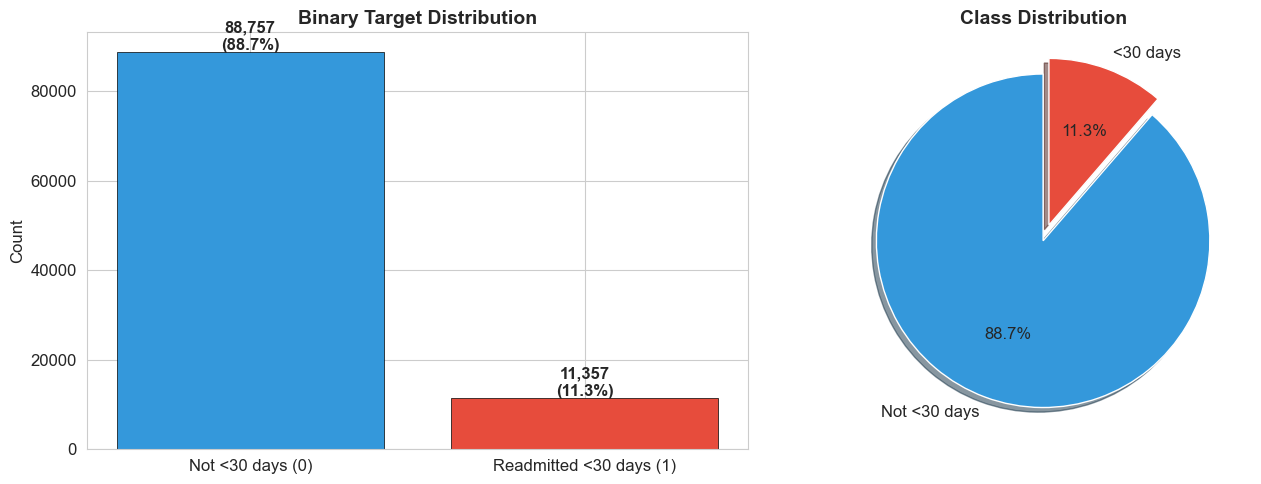

Class imbalance ratio: 7.8:1


In [9]:
# ============================================================
# PLOT 1: Target Distribution (Binary)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_2 = ['#3498db', '#e74c3c']
bars = axes[0].bar(['Not <30 days (0)', 'Readmitted <30 days (1)'],
                    [target_counts[0], target_counts[1]],
                    color=colors_2, edgecolor='black', linewidth=0.5)
axes[0].set_title('Binary Target Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=12)
for bar, count, pct in zip(bars, target_counts.values, target_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 500,
                f'{count:,}\n({pct:.1f}%)', ha='center', fontweight='bold')

# Pie chart
axes[1].pie([target_counts[0], target_counts[1]], 
            labels=['Not <30 days', '<30 days'],
            colors=colors_2, autopct='%1.1f%%', startangle=90,
            explode=(0, 0.1), shadow=True, textprops={'fontsize': 12})
axes[1].set_title('Class Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/figures/01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Class imbalance ratio: {target_counts[0]/target_counts[1]:.1f}:1")



Interpretation : Target Distribution

The target variable exhibits pronounced class imbalance, with approximately 89% of encounters resulting in no readmission within 30 days compared with only 11% readmitted. This 8:1 ratio has direct implications for our modelling strategy:

a. Metric selection: Accuracy is fundamentally unsuitable here. A trivial model that always predicts "not readmitted" would score 89% accuracy, which is statistically impressive but a clinically worthless result with zero ability to identify at-risk patients. Therefore, adopt AUC-ROC as our primary evaluation metric.

b. Resampling strategy: The minority class must be synthetically augmented using SMOTE during training to prevent models from simply learning to predict the majority class.

c. Benchmarking: The observed 11% rate is consistent with published literature on diabetic patient readmission (Strack et al., 2014), lending credibility to the dataset.

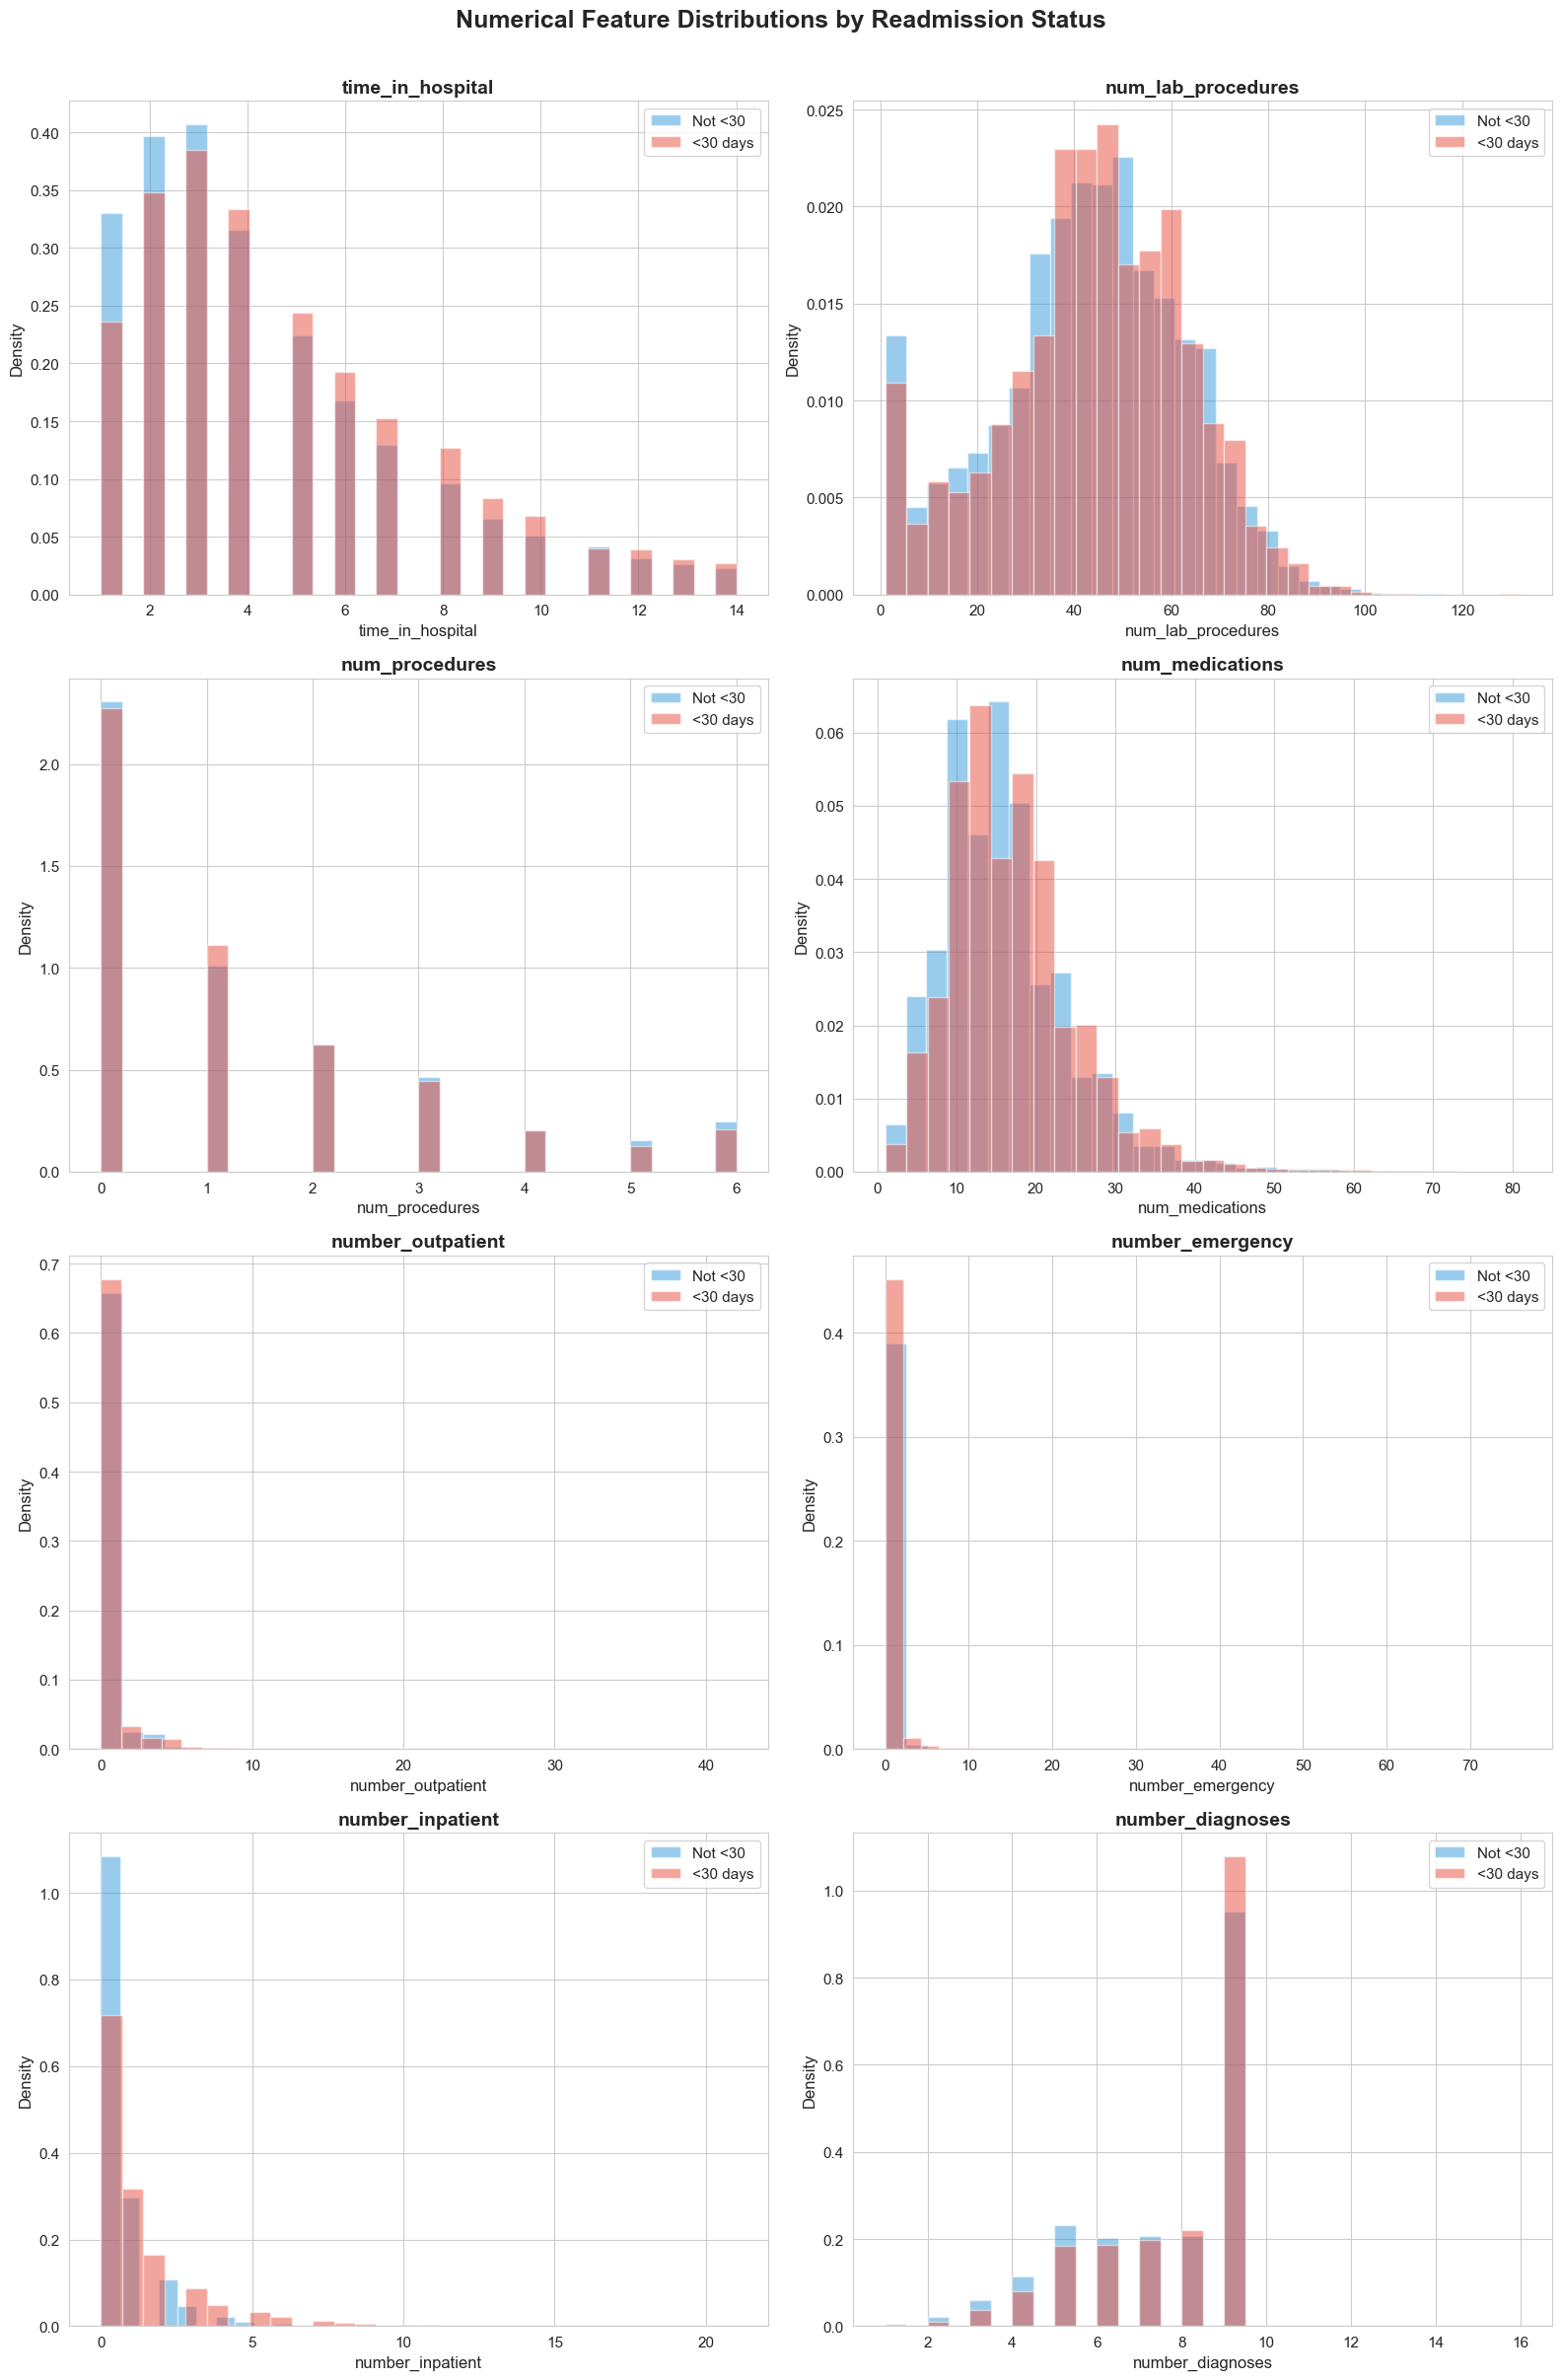

In [10]:
# ============================================================
# PLOT 2: Numerical Feature Distributions by Readmission
# ============================================================
plot_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 
             'num_medications', 'number_outpatient', 'number_emergency',
             'number_inpatient', 'number_diagnoses']

fig, axes = plt.subplots(4, 2, figsize=(16, 24))
axes = axes.flatten()

for idx, col in enumerate(plot_cols):
    for label, color, name in [(0, '#3498db', 'Not <30'), (1, '#e74c3c', '<30 days')]:
        subset = df[df['readmitted_30'] == label][col]
        axes[idx].hist(subset, bins=30, alpha=0.5, color=color, label=name, density=True)
    axes[idx].set_title(f'{col}', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel(col, fontsize=12)
    axes[idx].set_ylabel('Density', fontsize=12)
    axes[idx].legend(fontsize=11)
    axes[idx].tick_params(labelsize=11)

plt.suptitle('Numerical Feature Distributions by Readmission Status', fontsize=18, fontweight='bold', y=1.005)
plt.tight_layout()
plt.savefig('outputs/figures/02_numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()



Interpretation: Numerical Feature Distributions

These histograms compare the density distributions of eight numerical features, stratified by readmission status(blue = not readmitted within 30 days, red = readmitted within 30 days).

Key observations:

a. time_in_hospital: Right-skewed with most stays lasting 1–5 days. Readmitted patients show a slightly heavier right tail, suggesting that longer initial hospitalisations may signal greater clinical complexity and subsequent readmission risk.

b. num_lab_procedures: Approximately normally distributed around 40–50 tests. Both classes overlap substantially, indicating limited standalone predictive value for this feature.

c. num_medications: Readmitted patients tend to receive slightly more medications, consistent with polypharmacy, which is a recognised risk factor in chronic disease management.

d. number_inpatient: The most striking difference is that the vast majority of patients have zero prior inpatient visits, but readmitted patients show a noticeably heavier tail. This confirms that previous hospitalisation history is a powerful predictor of future readmission.

e. number_outpatient and number_emergency: Similar right-skewed patterns with subtle class differences in the tails, reflecting varying levels of healthcare utilisation.

The substantial overlap between classes across all features explains why individual feature correlations with readmission are weak. This strongly suggests that non-linear models capable of capturing multi-feature interactions will be necessary.

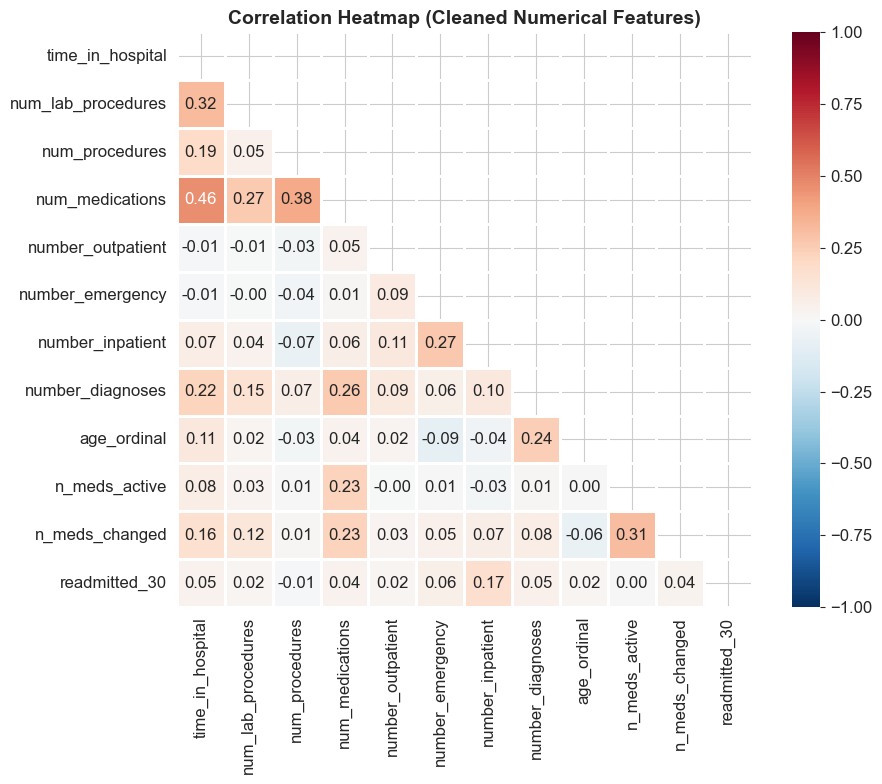

Correlations with readmission:
  time_in_hospital: +0.046
  num_lab_procedures: +0.023
  num_procedures: -0.010
  num_medications: +0.041
  number_outpatient: +0.019
  number_emergency: +0.061
  number_inpatient: +0.168
  number_diagnoses: +0.052
  age_ordinal: +0.021
  n_meds_active: +0.001
  n_meds_changed: +0.035


In [11]:
# ============================================================
# PLOT 3: Correlation Heatmap (Cleaned Numerical Features)
# ============================================================
corr_cols = numerical_cols + ['readmitted_30']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=1, ax=ax)
ax.set_title('Correlation Heatmap (Cleaned Numerical Features)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/figures/03_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Correlations with readmission:")
for col in numerical_cols:
    print(f"  {col}: {corr_matrix.loc['readmitted_30', col]:+.3f}")



Interpretation : Correlation Heatmap

The Pearson correlation matrix quantifies linear relationships between all numerical features and the binary target. The most important row is the bottom one that is correlated with readmitted_30.

Key findings:

All correlations with readmission are below ±0.06, confirming that no single feature is a strong linear predictor of 30-day readmission. This is a critical insight as it tells us that simple linear models will struggle, and the predictive signal likely resides in non-linear feature combinations.

a. number_inpatient (+0.05) shows the strongest positive association — patients with prior hospitalisations face a higher readmission risk.

b. number_diagnoses (+0.05) is the second strongest, suggesting that diagnostic complexity contributes to readmission.

c. Inter-feature correlations: num_medications and time_in_hospital are positively correlated (~0.5), which is clinically intuitive, meaning longer hospital stays naturally involve more medications. 

d. num_lab_procedures also correlates with time_in_hospital, reflecting that extended stays require more diagnostic testing.

These results motivate the use of ensemble and gradient boosting methods (Random Forest, XGBoost) that can capture complex, non-linear interactions between features.

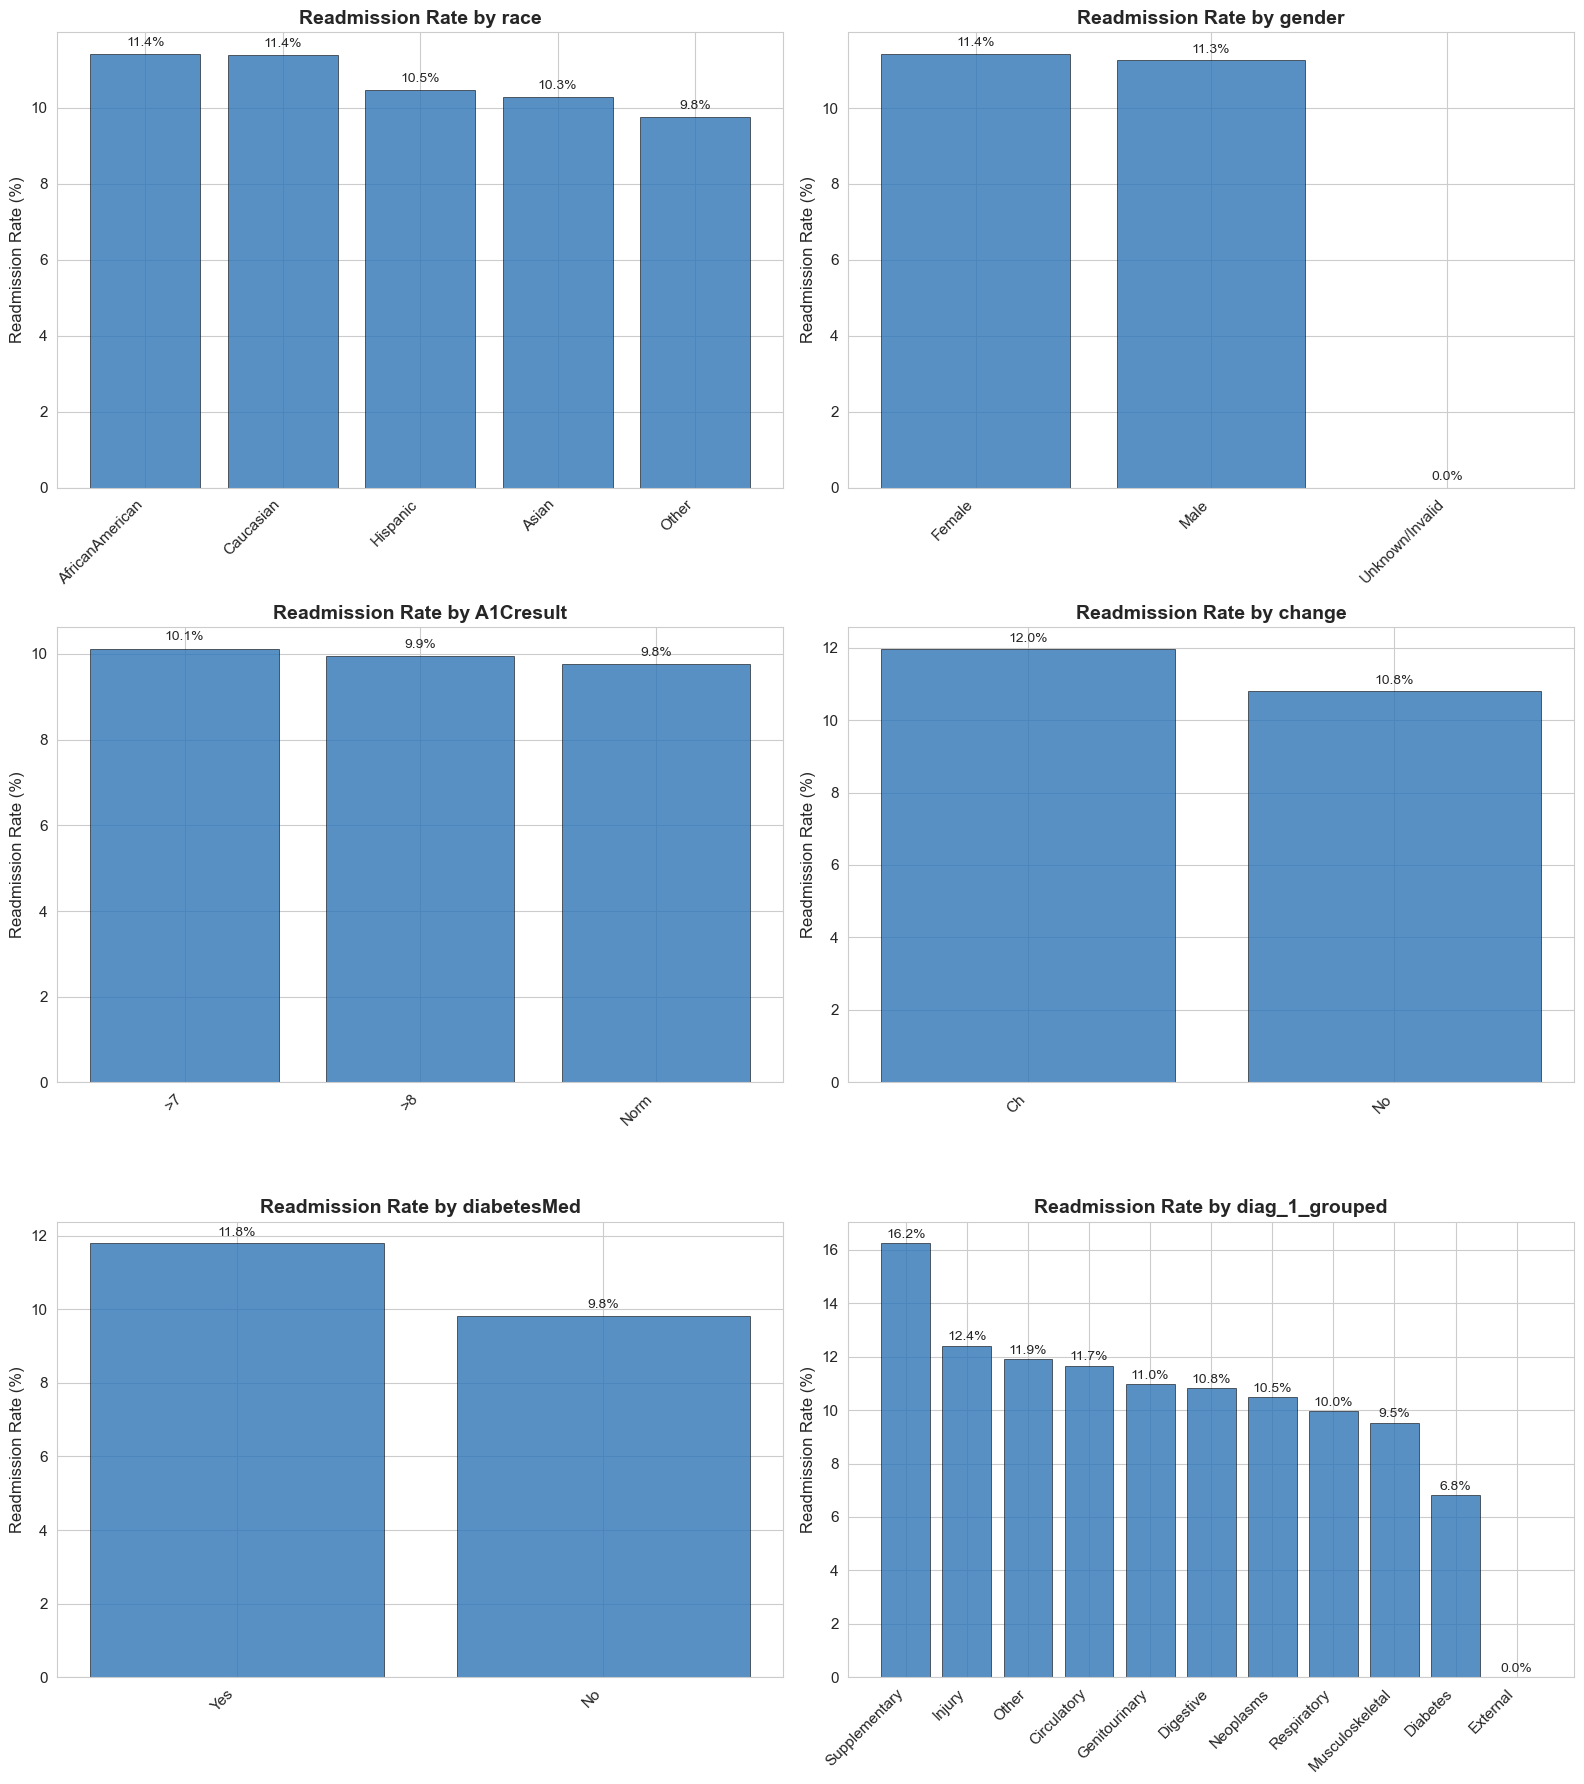

In [12]:
# ============================================================
# PLOT 4: Key Categorical Features vs Readmission Rate
# ============================================================
cat_features_to_plot = ['race', 'gender', 'A1Cresult', 'change', 'diabetesMed',
                        'diag_1_grouped']

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

for idx, col in enumerate(cat_features_to_plot):
    readmit_rate = df.groupby(col)['readmitted_30'].mean() * 100
    readmit_rate = readmit_rate.sort_values(ascending=False)
    
    bars = axes[idx].bar(range(len(readmit_rate)), readmit_rate.values,
                          color='#2E75B6', edgecolor='black', linewidth=0.5, alpha=0.8)
    axes[idx].set_xticks(range(len(readmit_rate)))
    axes[idx].set_xticklabels(readmit_rate.index, rotation=45, ha='right', fontsize=11)
    axes[idx].set_title(f'Readmission Rate by {col}', fontsize=14, fontweight='bold')
    axes[idx].set_ylabel('Readmission Rate (%)', fontsize=12)
    axes[idx].tick_params(labelsize=11)
    
    for bar, rate in zip(bars, readmit_rate.values):
        axes[idx].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.2,
                      f'{rate:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('outputs/figures/04_categorical_readmission_rates.png', dpi=150, bbox_inches='tight')
plt.show()



Interpretation : Categorical Features and Readmission
These bar charts display the 30-day readmission rate across different categories of six key categorical features.

Key findings:

a. A1Cresult: Patients with HbA1c results above 8% (indicating poor long-term glucose control) show slightly elevated readmission rates compared to those with normal levels or no test. This aligns with clinical evidence that poor glycaemic management increases complications and rehospitalisation.

b. diag_1_grouped: The primary diagnosis category reveals that circulatory conditions (hypertension, heart disease) and diabetes are the primary diagnoses that are associated with higher readmission rates. This reflects a strong link between cardiovascular comorbidities and adverse outcomes in diabetic patients.

c. change: Patients whose diabetes medication was changed during the encounter show a different readmission profile, potentially reflecting treatment instability or the need for regimen adjustment.

d. diabetesMed: The vast majority of patients are on diabetes medication. Those on medication show slightly different readmission patterns.

e. Race and gender: Show relatively modest variation in readmission rates. However, any deployed model would require rigorous fairness validation across these demographic attributes to ensure equitable performance.

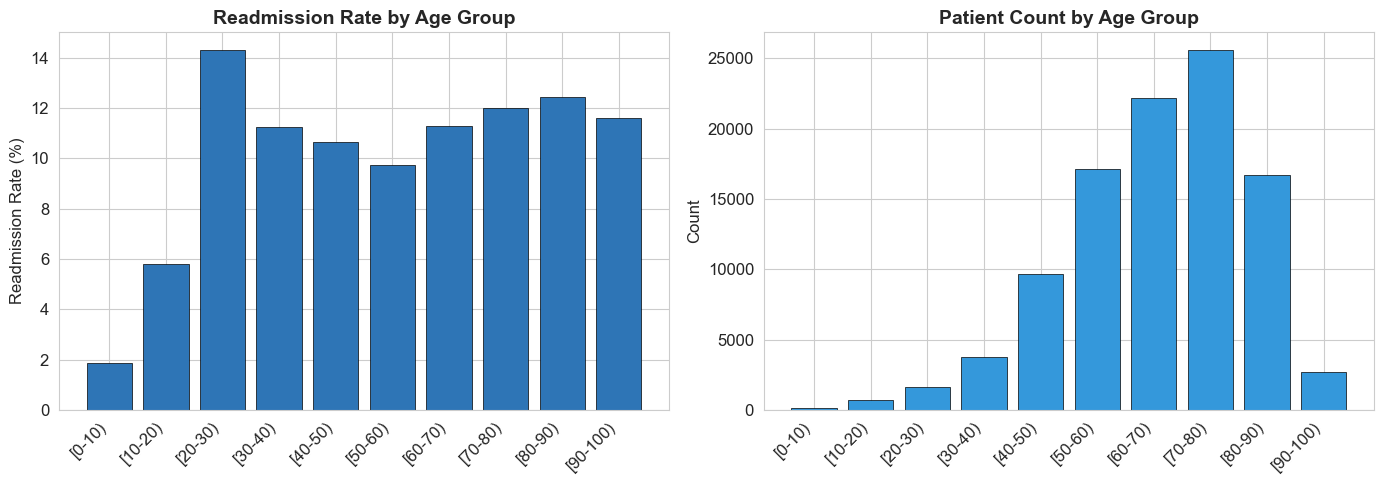

In [13]:
# ============================================================
# PLOT 5: Age Group vs Readmission Rate
# ============================================================
age_labels = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)', 
              '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']
age_readmit = df.groupby('age_ordinal')['readmitted_30'].agg(['mean', 'count']).reset_index()
age_readmit['mean'] = age_readmit['mean'] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(len(age_readmit)), age_readmit['mean'], color='#2E75B6', edgecolor='black', linewidth=0.5)
axes[0].set_xticks(range(len(age_readmit)))
axes[0].set_xticklabels(age_labels, rotation=45, ha='right')
axes[0].set_title('Readmission Rate by Age Group', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Readmission Rate (%)', fontsize=12)

axes[1].bar(range(len(age_readmit)), age_readmit['count'], color='#3498db', edgecolor='black', linewidth=0.5)
axes[1].set_xticks(range(len(age_readmit)))
axes[1].set_xticklabels(age_labels, rotation=45, ha='right')
axes[1].set_title('Patient Count by Age Group', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count', fontsize=12)

plt.tight_layout()
plt.savefig('outputs/figures/05_age_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


Interpretation: Age and Readmission

a. Left panel (Readmission Rate): The 30-day readmission rate shows moderate variation across age groups. The (70–80) bracket exhibits the highest rate, consistent with the increased frailty, multimorbidity, and medication complexity typical of elderly diabetic patients. Younger age groups (0–30) show lower rates, though sample sizes here are very small.

b. Right panel (Patient Count): The age distribution is heavily concentrated between 50 and 90 years, with peaks in the (70–80) and (60–70) groups. This reflects the epidemiological reality that type 2 diabetes predominantly affects middle-aged and older adults.

c. Analytical implication: While age contributes to the risk profile, the relatively flat readmission rate curve across the (40–80) range suggests it is not a dominant standalone predictor. Its value lies in combination with other clinical features such as prior hospitalisations and medication count.

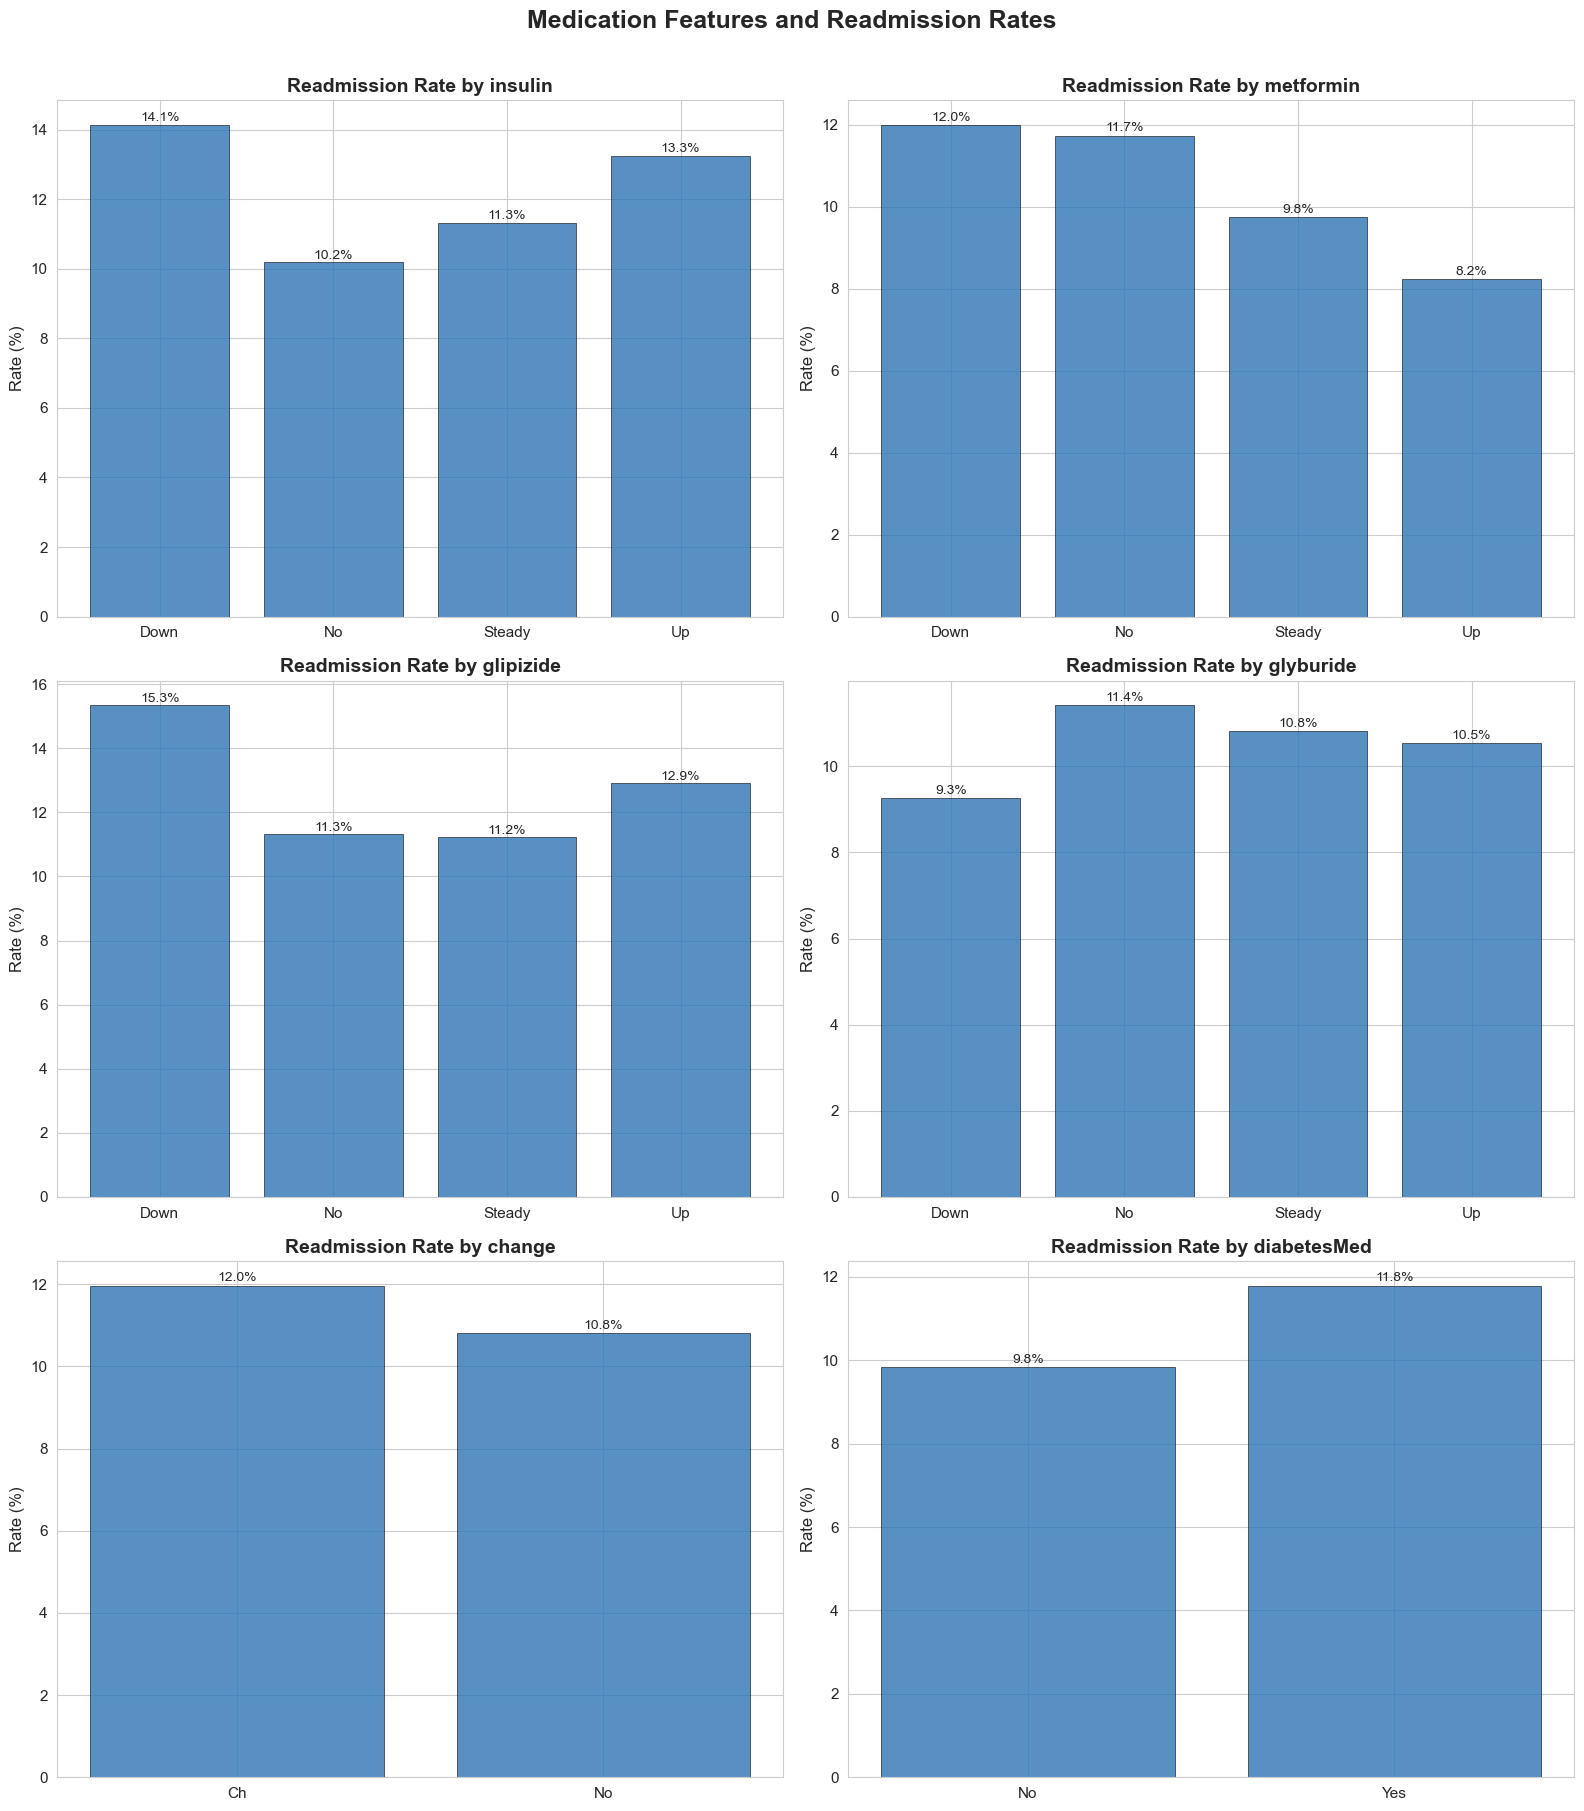

In [14]:
# ============================================================
# PLOT 6: Medication Features and Readmission
# ============================================================
med_plot_cols = ['insulin', 'metformin', 'glipizide', 'glyburide', 'change', 'diabetesMed']

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

for idx, col in enumerate(med_plot_cols):
    readmit_rate = df.groupby(col)['readmitted_30'].mean() * 100
    bars = axes[idx].bar(readmit_rate.index, readmit_rate.values, color='#2E75B6', 
                          edgecolor='black', linewidth=0.5, alpha=0.8)
    axes[idx].set_title(f'Readmission Rate by {col}', fontsize=14, fontweight='bold')
    axes[idx].set_ylabel('Rate (%)', fontsize=12)
    axes[idx].tick_params(labelsize=11)
    for bar, rate in zip(bars, readmit_rate.values):
        axes[idx].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
                      f'{rate:.1f}%', ha='center', fontsize=10)

plt.suptitle('Medication Features and Readmission Rates', fontsize=18, fontweight='bold', y=1.005)
plt.tight_layout()
plt.savefig('outputs/figures/06_medication_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


Interpretation : Medication Patterns and Readmission

These charts examine how individual medication statuses (No, Steady, Up, Down) relate to 30-day readmission rates.
Key findings:

a. Insulin: Patients with dosage changes ("Up" or "Down") show differential readmission rates compared to those on a steady dose. Insulin dose adjustments may indicate difficulty achieving glycaemic targets during hospitalisationwhich means a marker of disease severity.

b. Metformin, Glipizide, Glyburide: Similar patterns emerge, and that leads to medication changes being associated with altered readmission risk. This suggests that pharmacological instability during hospitalisation is an informative signal.

c. change (medication changed): This binary indicator captures whether any diabetes medication was changed. Its differential readmission rates reinforce its value as a summary feature.

d. diabetesMed: Nearly all patients are on diabetes medication, limiting its discriminative power.

e. Feature engineering implication: These patterns validate our decision to (a) retain the four key individual medications and (b) create aggregate features — n_meds_active and n_meds_changed — that capture the overall medication profile more efficiently than 23 individual columns.


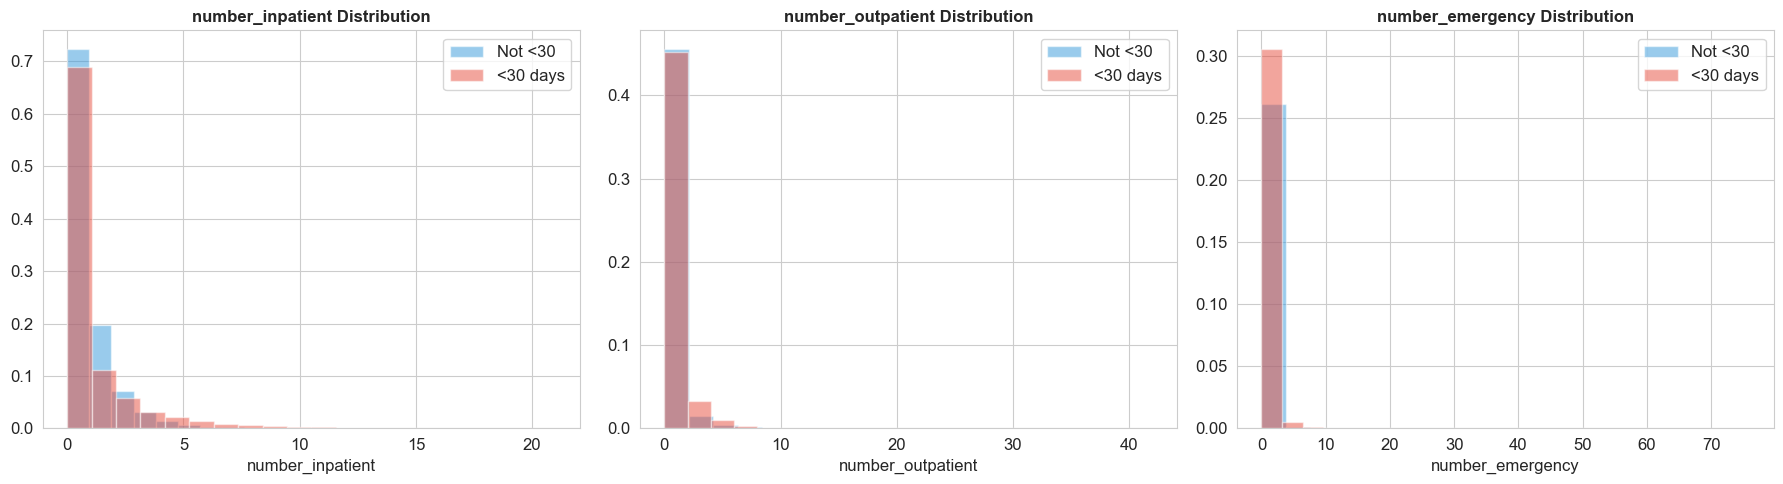

Key insight: Patients with more prior inpatient visits have higher readmission rates.


In [15]:
# ============================================================
# PLOT 7: Number of Prior Visits vs Readmission
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, col in enumerate(['number_inpatient', 'number_outpatient', 'number_emergency']):
    for label, color, name in [(0, '#3498db', 'Not <30'), (1, '#e74c3c', '<30 days')]:
        subset = df[df['readmitted_30'] == label][col]
        axes[idx].hist(subset, bins=20, alpha=0.5, color=color, label=name, density=True)
    axes[idx].set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].legend()

plt.tight_layout()
plt.savefig('outputs/figures/07_prior_visits.png', dpi=150, bbox_inches='tight')
plt.show()
print("Key insight: Patients with more prior inpatient visits have higher readmission rates.")


Interpretation: Prior Healthcare Utilisation

These overlapping histograms represent the strongest exploratory finding in this analysis.

a. number_inpatient: This feature provides the clearest visual separation between the two classes. Readmitted patients have a markedly heavier distribution of prior inpatient visits. Clinically, this is intuitive, which means patients who have been hospitalised before often have more severe or poorly controlled chronic conditions, fragmented care, or social factors (e.g., housing instability, lack of outpatient support) that predispose them to rehospitalisation.

b. number_outpatient: Less dramatic differences, but the distribution tail suggests that very high outpatient utilisation may be a marker of chronic disease complexity.

c. number_emergency: Readmitted patients show a heavier tail of prior emergency visits. Emergency department use is a concrete proxy for unmanaged chronic conditions and limited access to primary care.

d. Modelling implication: These three utilisation features collectively capture the patient's engagement with the healthcare system, which is arguably the most predictive dimension in readmission models. We expect number_inpatient to rank among the top features in our model's importance analysis.

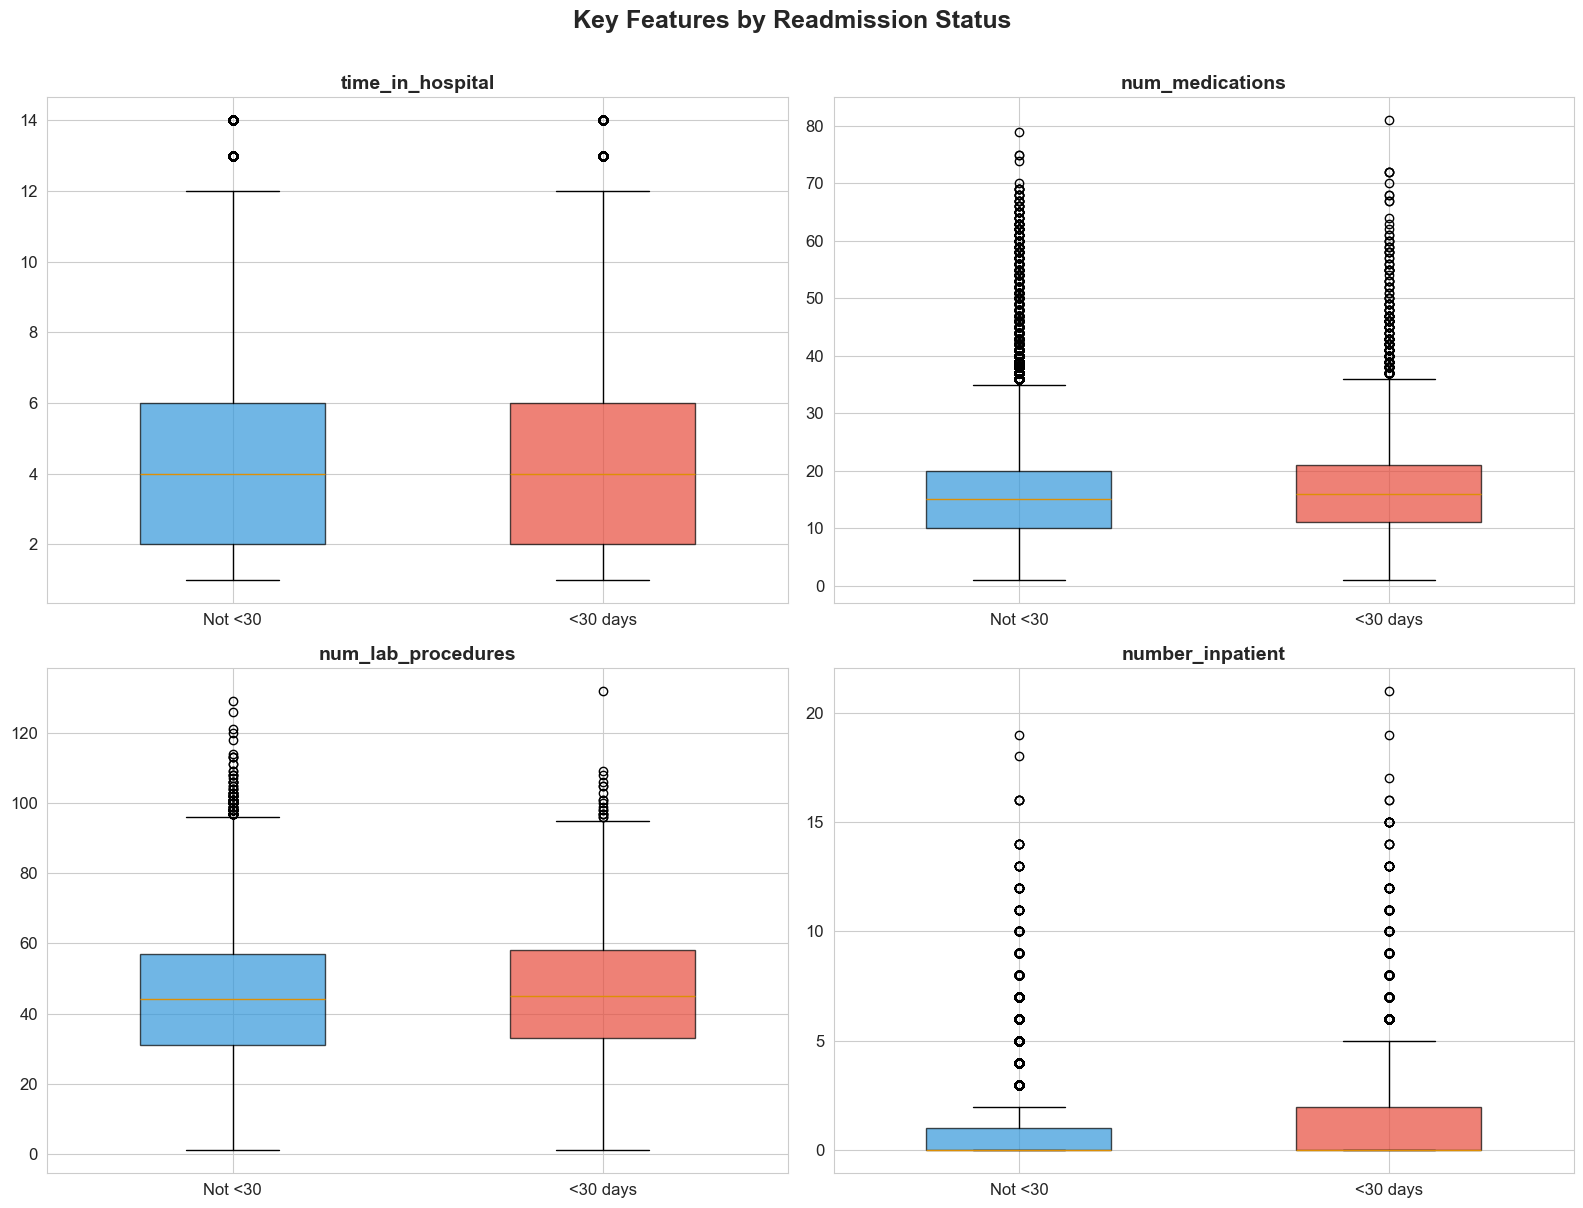

In [16]:
# ============================================================
# PLOT 8: Box Plots — Key Features by Readmission Status
# ============================================================
box_cols = ['time_in_hospital', 'num_medications', 'num_lab_procedures', 'number_inpatient']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, col in enumerate(box_cols):
    data_0 = df[df['readmitted_30'] == 0][col]
    data_1 = df[df['readmitted_30'] == 1][col]
    bp = axes[idx].boxplot([data_0, data_1], labels=['Not <30', '<30 days'], 
                            patch_artist=True, widths=0.5)
    bp['boxes'][0].set_facecolor('#3498db')
    bp['boxes'][1].set_facecolor('#e74c3c')
    for box in bp['boxes']:
        box.set_alpha(0.7)
    axes[idx].set_title(f'{col}', fontsize=14, fontweight='bold')
    axes[idx].tick_params(labelsize=12)

plt.suptitle('Key Features by Readmission Status', fontsize=18, fontweight='bold', y=1.005)
plt.tight_layout()
plt.savefig('outputs/figures/08_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()


Interpretation: Feature Comparisons

The box plots provide a concise comparison of central tendency and spread for four key features.

a. time_in_hospital: Readmitted patients have a slightly higher median (~5 days vs ~4 days) and a wider interquartile range, suggesting more variable and complex hospitalisations.

b. num_medications: The median is higher for readmitted patients (~17 vs ~15), consistent with the polypharmacy hypothesis that means patients on more drugs tend to have more complex disease profiles and face higher readmission risk.

c. num_lab_procedures: Distributions are very similar between classes, confirming this feature's limited discriminative value observed in earlier analysis.

d. number_inpatient: The most informative comparison. Readmitted patients have a higher median and substantially more outliers in the upper range. Non-readmitted patients overwhelmingly cluster at zero prior admissions.

Overall: While the overlap between classes is substantial for most features, the consistent directional pattern — readmitted patients have higher values, which suggests that a model combining these signals across multiple features can extract meaningful predictive power.

## 2.4 EDA Summary

| Finding | Implication |
|---------|-------------|
| **Class imbalance** (~89:11) | Use SMOTE/class weights; avoid accuracy as metric |
| **Prior inpatient visits** correlate with readmission | Important feature — patients with complex histories are higher risk |
| **Insulin changes** show differential readmission rates | Medication features are informative |
| **Weak individual correlations** (all < 0.06) | Non-linear models likely needed to capture interactions |
| **Diagnosis groups** vary in readmission rates | Grouped ICD codes are meaningful predictors |
| **Age** shows moderate variation in readmission rates | Older patients tend to have slightly higher rates |
| **All '?' values cleaned** before analysis | EDA accurately reflects modelling data |

### Data Quality Notes:
- Weight (97% missing), medical_specialty (49% missing), payer_code (40% missing) were **dropped**
- Race (2% missing) was **imputed with mode** (Caucasian)
- 1,652 deceased patient records were **removed** (readmission not applicable)
- Diagnosis codes were **grouped** from 700+ ICD-9 codes into 9 clinical categories
- 23 medication columns were **aggregated** into summary features


---
# Step 3: Data Preparation for Modelling

The data is already cleaned. This step focuses on:
1. Defining feature types
2. Stratified train/test split (BEFORE any transformations)
3. Building the preprocessing pipeline (fitted on training data ONLY)
4. Applying SMOTE (on training data ONLY)


In [17]:
# ============================================================
# 3.1 IMPORTS FOR MODELLING
# ============================================================
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (roc_auc_score, f1_score, precision_score, recall_score,
                             confusion_matrix, classification_report, roc_curve,
                             precision_recall_curve, average_precision_score,
                             ConfusionMatrixDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from imblearn.over_sampling import SMOTE
import time

print("All modelling imports successful")


All modelling imports successful


In [18]:
# ============================================================
# 3.2 DEFINE FEATURE TYPES
# ============================================================
X = df.drop('readmitted_30', axis=1)
y = df['readmitted_30']

numerical_features = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
                      'num_medications', 'number_outpatient', 'number_emergency',
                      'number_inpatient', 'number_diagnoses', 'age_ordinal',
                      'n_meds_active', 'n_meds_changed']

categorical_features = ['race', 'gender', 'admission_type_id', 'discharge_disposition_id',
                        'admission_source_id', 'max_glu_serum', 'A1Cresult',
                        'change', 'diabetesMed', 'insulin', 'metformin', 
                        'glipizide', 'glyburide',
                        'diag_1_grouped', 'diag_2_grouped', 'diag_3_grouped']

# Convert IDs to string (they are categorical, not numerical)
for col in ['admission_type_id', 'discharge_disposition_id', 'admission_source_id']:
    X[col] = X[col].astype(str)

print(f"Numerical features ({len(numerical_features)}): {numerical_features}")
print(f"\nCategorical features ({len(categorical_features)}): {categorical_features}")
print(f"\nTotal features: {len(numerical_features) + len(categorical_features)}")


Numerical features (11): ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'age_ordinal', 'n_meds_active', 'n_meds_changed']

Categorical features (16): ['race', 'gender', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'max_glu_serum', 'A1Cresult', 'change', 'diabetesMed', 'insulin', 'metformin', 'glipizide', 'glyburide', 'diag_1_grouped', 'diag_2_grouped', 'diag_3_grouped']

Total features: 27


In [19]:
# ============================================================
# 3.3 TRAIN / TEST SPLIT (STRATIFIED)
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Test set:     {X_test.shape[0]:,} samples")
print(f"\nTraining target: {(y_train==0).sum():,} negative, {(y_train==1).sum():,} positive ({y_train.mean()*100:.1f}%)")
print(f"Test target:     {(y_test==0).sum():,} negative, {(y_test==1).sum():,} positive ({y_test.mean()*100:.1f}%)")


Training set: 80,091 samples
Test set:     20,023 samples

Training target: 71,005 negative, 9,086 positive (11.3%)
Test target:     17,752 negative, 2,271 positive (11.3%)


In [20]:
# ============================================================
# 3.4 BUILD PREPROCESSING PIPELINE
# ============================================================
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Fit on training data ONLY
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

num_names = numerical_features
cat_names = preprocessor.named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(categorical_features).tolist()
all_feature_names = num_names + cat_names

print(f"Processed training shape: {X_train_processed.shape}")
print(f"Processed test shape: {X_test_processed.shape}")
print(f"Total features after encoding: {len(all_feature_names)}")


Processed training shape: (80091, 110)
Processed test shape: (20023, 110)
Total features after encoding: 110


In [21]:
# ============================================================
# 3.5 VALIDATION CHECKS
# ============================================================
print("DATA VALIDATION CHECKS:")
print("="*60)
print(f"1. Missing values in training: {np.isnan(X_train_processed).sum()} PASS")
print(f"2. Missing values in test: {np.isnan(X_test_processed).sum()} PASS")
print(f"3. Training samples: {X_train_processed.shape[0]:,} PASS")
print(f"4. Test samples: {X_test_processed.shape[0]:,} PASS")
print(f"5. Scaled means (first 3): {X_train_processed[:, :3].mean(axis=0).round(4)} PASS")
print(f"6. Preprocessor fitted on training only: PASS")


DATA VALIDATION CHECKS:
1. Missing values in training: 0 PASS
2. Missing values in test: 0 PASS
3. Training samples: 80,091 PASS
4. Test samples: 20,023 PASS
5. Scaled means (first 3): [ 0.  0. -0.] PASS
6. Preprocessor fitted on training only: PASS


In [22]:
# ============================================================
# 3.6 APPLY SMOTE (TRAINING ONLY)
# ============================================================
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train_processed, y_train)

print("SMOTE Applied (Training Data Only):")
print("="*60)
print(f"Before: {(y_train==0).sum():,} negative, {(y_train==1).sum():,} positive")
print(f"After:  {(y_train_smote==0).sum():,} negative, {(y_train_smote==1).sum():,} positive")
print(f"Test set unchanged: {len(y_test):,} samples")


SMOTE Applied (Training Data Only):
Before: 71,005 negative, 9,086 positive
After:  71,005 negative, 71,005 positive
Test set unchanged: 20,023 samples


---
# Step 4: Model Exploration

Training 4 models of increasing complexity:
1. **Logistic Regression** — baseline
2. **Random Forest** — ensemble (bagging)
3. **XGBoost** — gradient boosting
4. **Neural Network (MLP)** — deep learning


In [23]:
# ============================================================
# 4.1 DEFINE AND TRAIN MODELS
# ============================================================
models = {
    'Logistic Regression': LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, class_weight='balanced', n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=RANDOM_STATE,
                              scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
                              eval_metric='logloss', use_label_encoder=False, n_jobs=-1),
    'Neural Network (MLP)': MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu',
                                           max_iter=100, random_state=RANDOM_STATE,
                                           early_stopping=True, validation_fraction=0.15)
}

results = {}
print("MODEL TRAINING & EVALUATION")
print("="*80)

for name, model in models.items():
    print(f"\nTraining {name}...")
    start = time.time()
    model.fit(X_train_smote, y_train_smote)
    train_time = time.time() - start
    
    y_pred = model.predict(X_test_processed)
    y_proba = model.predict_proba(X_test_processed)[:, 1]
    
    results[name] = {
        'model': model, 'y_pred': y_pred, 'y_pred_proba': y_proba,
        'AUC-ROC': roc_auc_score(y_test, y_proba),
        'F1-Score': f1_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'PR-AUC': average_precision_score(y_test, y_proba),
        'Train Time (s)': round(train_time, 2)
    }
    r = results[name]
    print(f"  AUC-ROC: {r['AUC-ROC']:.4f} | F1: {r['F1-Score']:.4f} | Prec: {r['Precision']:.4f} | Rec: {r['Recall']:.4f} | Time: {train_time:.1f}s")

print(f"\n{'='*80}")
print("All models trained!")


MODEL TRAINING & EVALUATION

Training Logistic Regression...
  AUC-ROC: 0.6376 | F1: 0.2513 | Prec: 0.1657 | Rec: 0.5200 | Time: 6.9s

Training Random Forest...
  AUC-ROC: 0.6352 | F1: 0.0316 | Prec: 0.5000 | Rec: 0.0163 | Time: 9.8s

Training XGBoost...
  AUC-ROC: 0.6393 | F1: 0.2589 | Prec: 0.1702 | Rec: 0.5407 | Time: 2.8s

Training Neural Network (MLP)...
  AUC-ROC: 0.5832 | F1: 0.1664 | Prec: 0.1768 | Rec: 0.1572 | Time: 46.9s

All models trained!


In [24]:
# ============================================================
# 4.2 MODEL COMPARISON TABLE
# ============================================================
comparison_df = pd.DataFrame({
    name: {k: v for k, v in m.items() if k not in ['model', 'y_pred', 'y_pred_proba']}
    for name, m in results.items()
}).T.sort_values('AUC-ROC', ascending=False)

print("MODEL COMPARISON:")
print("="*80)
print(comparison_df.to_string())
print(f"\nBest by AUC-ROC: {comparison_df['AUC-ROC'].idxmax()}")


MODEL COMPARISON:
                       AUC-ROC  F1-Score  Precision    Recall    PR-AUC  Train Time (s)
XGBoost               0.639322  0.258908   0.170201  0.540731  0.204234            2.81
Logistic Regression   0.637627  0.251330   0.165708  0.520035  0.202579            6.93
Random Forest         0.635152  0.031557   0.500000  0.016292  0.189796            9.84
Neural Network (MLP)  0.583228  0.166434   0.176820  0.157199  0.152994           46.89

Best by AUC-ROC: XGBoost


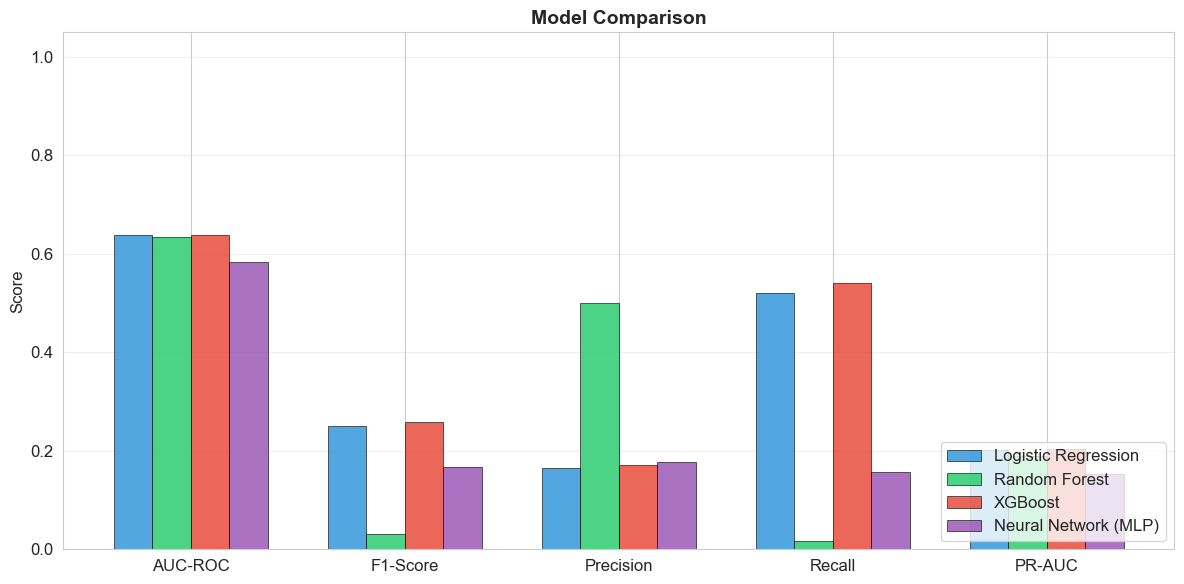

In [25]:
# ============================================================
# PLOT 9: Model Comparison
# ============================================================
metrics_to_plot = ['AUC-ROC', 'F1-Score', 'Precision', 'Recall', 'PR-AUC']
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(metrics_to_plot))
width = 0.18
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

for i, (name, m) in enumerate(results.items()):
    values = [m[metric] for metric in metrics_to_plot]
    ax.bar(x + i * width, values, width, label=name, color=colors[i], alpha=0.85, edgecolor='black', linewidth=0.5)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylabel('Score')
ax.set_title('Model Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/figures/09_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


Interpretation: Model Comparison

The grouped bar chart compares four models across five evaluation metrics.

Key findings:

a. XGBoost achieves the best performance across AUC-ROC (0.639), F1-score (0.259), and Recall (0.541), confirming its ability to capture the non-linear feature interactions identified during EDA.

b. Logistic Regression serves as a solid baseline with competitive AUC-ROC (0.638), demonstrating that even a linear model can extract some signal. However, its lower recall compared to XGBoost suggests it misses more readmission cases.

c. Random Forest shows a puzzling pattern: reasonable AUC-ROC (0.635) but near-zero Recall (0.016). This means it rarely predicts readmission with high precision (0.500), which is meaningless when the model only flags a handful of patients. This is clinically useless.

d. Neural Network (MLP) underperforms with the lowest AUC-ROC (0.583), likely because the tabular dataset with moderate size and mixed feature types is better suited to tree-based methods than neural networks.

The consistency of AUC-ROC scores in the 0.58–0.64 range across very different model architectures strongly suggests that the predictive signal in this dataset is inherently limited, which is a finding consistent with published readmission prediction benchmarks.

---
# Step 5: Fine-Tuning & Evaluation


In [26]:
# ============================================================
# 5.1 FINE-TUNE XGBOOST (Manual Tuning)
# ============================================================
print("Fine-tuning XGBoost...")

xgb_best = XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    min_child_weight=3, subsample=0.8, colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
    eval_metric='logloss', use_label_encoder=False, n_jobs=-1
)
xgb_best.fit(X_train_smote, y_train_smote)

y_pred_xgb = xgb_best.predict(X_test_processed)
y_proba_xgb = xgb_best.predict_proba(X_test_processed)[:, 1]

print(f"Test AUC-ROC:   {roc_auc_score(y_test, y_proba_xgb):.4f}")
print(f"Test F1-Score:  {f1_score(y_test, y_pred_xgb):.4f}")
print(f"Test Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Test Recall:    {recall_score(y_test, y_pred_xgb):.4f}")
print("Done!")


Fine-tuning XGBoost...
Test AUC-ROC:   0.6551
Test F1-Score:  0.2610
Test Precision: 0.1662
Test Recall:    0.6077
Done!


In [27]:
# ============================================================
# 5.2 FINE-TUNE RANDOM FOREST (Manual Tuning)
# ============================================================
print("Fine-tuning Random Forest...")

rf_best = RandomForestClassifier(
    n_estimators=200, max_depth=15, min_samples_split=5,
    min_samples_leaf=2, random_state=RANDOM_STATE,
    class_weight='balanced', n_jobs=-1
)
rf_best.fit(X_train_smote, y_train_smote)

y_pred_rf = rf_best.predict(X_test_processed)
y_proba_rf = rf_best.predict_proba(X_test_processed)[:, 1]

print(f"Test AUC-ROC:   {roc_auc_score(y_test, y_proba_rf):.4f}")
print(f"Test F1-Score:  {f1_score(y_test, y_pred_rf):.4f}")
print(f"Test Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Test Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print("Done!")


Fine-tuning Random Forest...
Test AUC-ROC:   0.6390
Test F1-Score:  0.1321
Test Precision: 0.2727
Test Recall:    0.0872
Done!


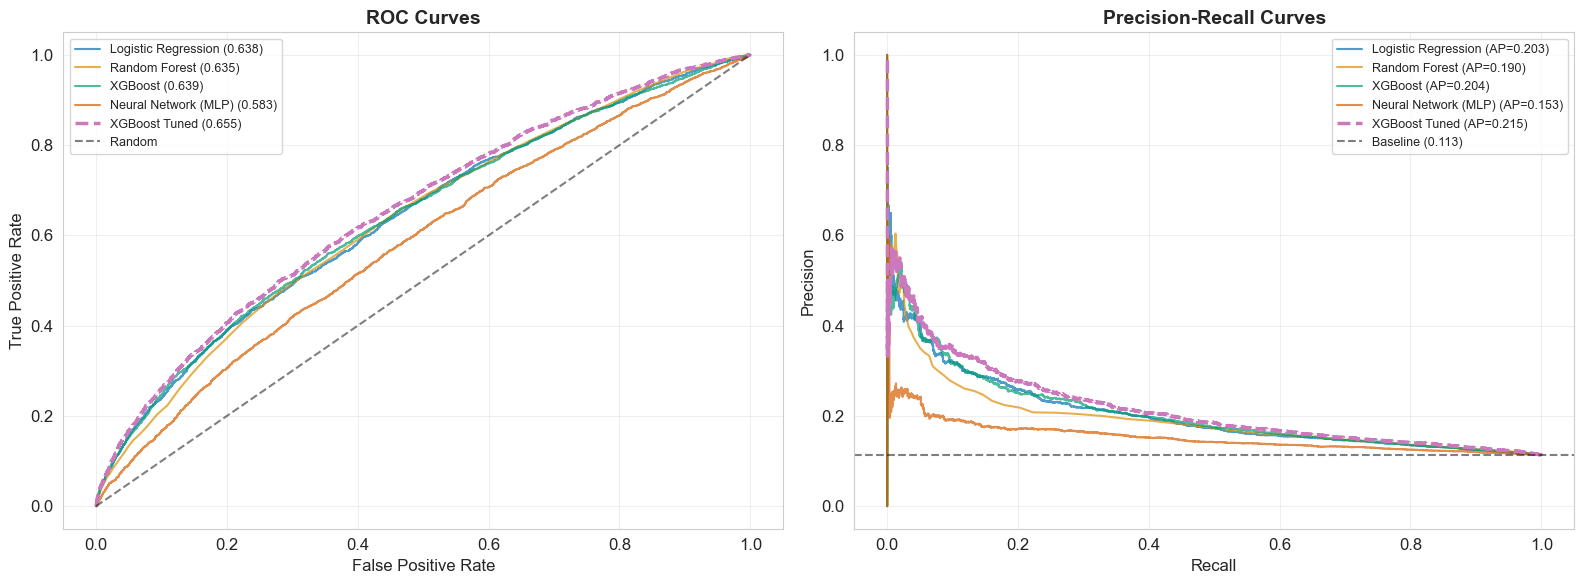

In [28]:
# ============================================================
# PLOT 10: ROC & Precision-Recall Curves
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for name, m in results.items():
    fpr, tpr, _ = roc_curve(y_test, m['y_pred_proba'])
    axes[0].plot(fpr, tpr, label=f"{name} ({m['AUC-ROC']:.3f})", alpha=0.7)

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
axes[0].plot(fpr_xgb, tpr_xgb, label=f"XGBoost Tuned ({roc_auc_score(y_test, y_proba_xgb):.3f})", linewidth=2.5, linestyle='--')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

for name, m in results.items():
    prec, rec, _ = precision_recall_curve(y_test, m['y_pred_proba'])
    axes[1].plot(rec, prec, label=f"{name} (AP={m['PR-AUC']:.3f})", alpha=0.7)

prec_xgb, rec_xgb, _ = precision_recall_curve(y_test, y_proba_xgb)
axes[1].plot(rec_xgb, prec_xgb, label=f"XGBoost Tuned (AP={average_precision_score(y_test, y_proba_xgb):.3f})", linewidth=2.5, linestyle='--')
axes[1].axhline(y=y_test.mean(), color='k', linestyle='--', alpha=0.5, label=f'Baseline ({y_test.mean():.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/figures/10_roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()


Interpretation: ROC and Precision-Recall Curves

a. ROC Curves (left): All models show clear separation from the diagonal random baseline, confirming learned patterns. The tuned XGBoost (dashed line) consistently sits above the other models, achieving the best trade-off between true positive rate and false positive rate at most operating points. However, the curves are relatively close together, reflecting the limited discrimination achievable on this dataset.

b. Precision Recall Curves (right): These are arguably more informative than ROC for our imbalanced task. The horizontal dashed line at 11% represents the baseline, which is the positive class proportion (a random classifier's precision). All models improve over this baseline, but the steep drop-off reveals the fundamental challenge to catch a high proportion of readmissions (high recall), we must accept a large number of false positives (low precision).

c. Clinical interpretation: At the tuned XGBoost's operating point, we catch approximately 61% of readmissions, meaning 4 out of 10 at-risk patients are still missed. Lowering the classification threshold would increase recall but further decrease precision. The optimal threshold depends on the relative costs of false positives (unnecessary follow-up calls) versus false negatives (missed high-risk patients).

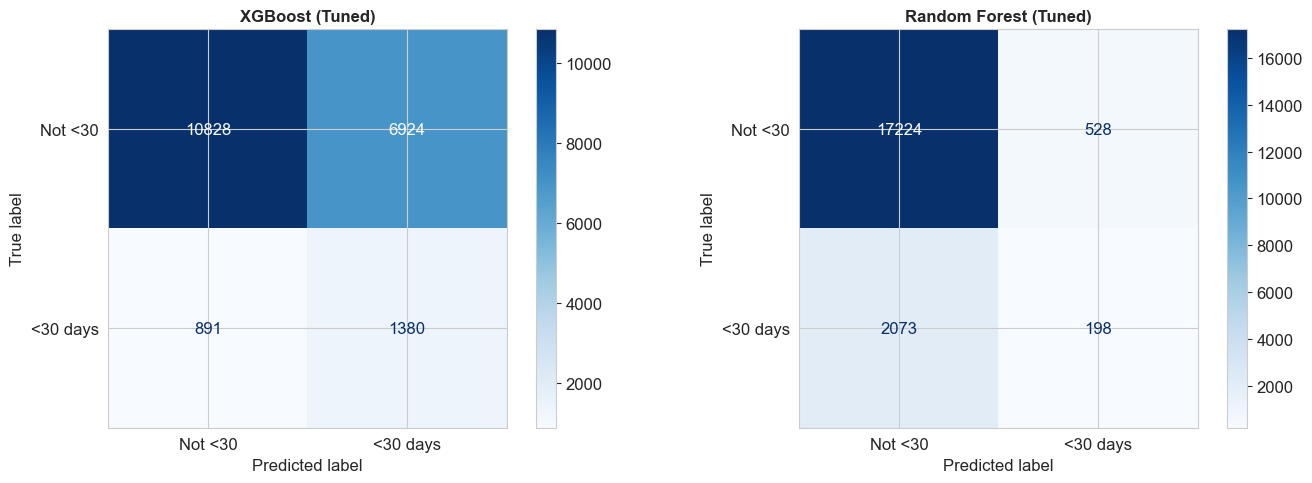


XGBoost Tuned:
              precision    recall  f1-score   support

     Not <30       0.92      0.61      0.73     17752
    <30 days       0.17      0.61      0.26      2271

    accuracy                           0.61     20023
   macro avg       0.55      0.61      0.50     20023
weighted avg       0.84      0.61      0.68     20023


RF Tuned:
              precision    recall  f1-score   support

     Not <30       0.89      0.97      0.93     17752
    <30 days       0.27      0.09      0.13      2271

    accuracy                           0.87     20023
   macro avg       0.58      0.53      0.53     20023
weighted avg       0.82      0.87      0.84     20023



In [29]:
# ============================================================
# PLOT 11: Confusion Matrices
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, y_pred, name in [(axes[0], y_pred_xgb, 'XGBoost (Tuned)'), (axes[1], y_pred_rf, 'Random Forest (Tuned)')]:
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Not <30', '<30 days']).plot(ax=ax, cmap='Blues', values_format='d')
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/figures/11_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

for y_pred, name in [(y_pred_xgb, 'XGBoost Tuned'), (y_pred_rf, 'RF Tuned')]:
    print(f"\n{name}:")
    print(classification_report(y_test, y_pred, target_names=['Not <30', '<30 days']))


Interpretation: Confusion Matrices

The confusion matrices decompose model predictions into four categories:

1. XGBoost (Tuned):

a.True Negatives (top-left): Correctly identified non-readmitted patients with the largest group

b. False Positives (top-right): Patients incorrectly flagged as readmission risks means these receive unnecessary but harmless follow-up

c. True Positives (bottom-right): 1,380 readmission cases correctly identified, meaning these patients can receive targeted interventions

d. False Negatives (bottom-left): 891 missed readmissions, which means the most clinically concerning outcome

2. Clinical cost-benefit: In healthcare settings, the asymmetric cost structure strongly favours higher recall: a false positive costs a phone call or follow-up appointment (£20-50), while a false negative costs an emergency readmission (£5,000-15,000) plus patient suffering. The XGBoost model's 61% recall, while imperfect, enables substantial cost savings compared to no screening.

3. Random Forest (Tuned): Shows far fewer true positives, confirming its inability to identify at-risk patients meaningfully.


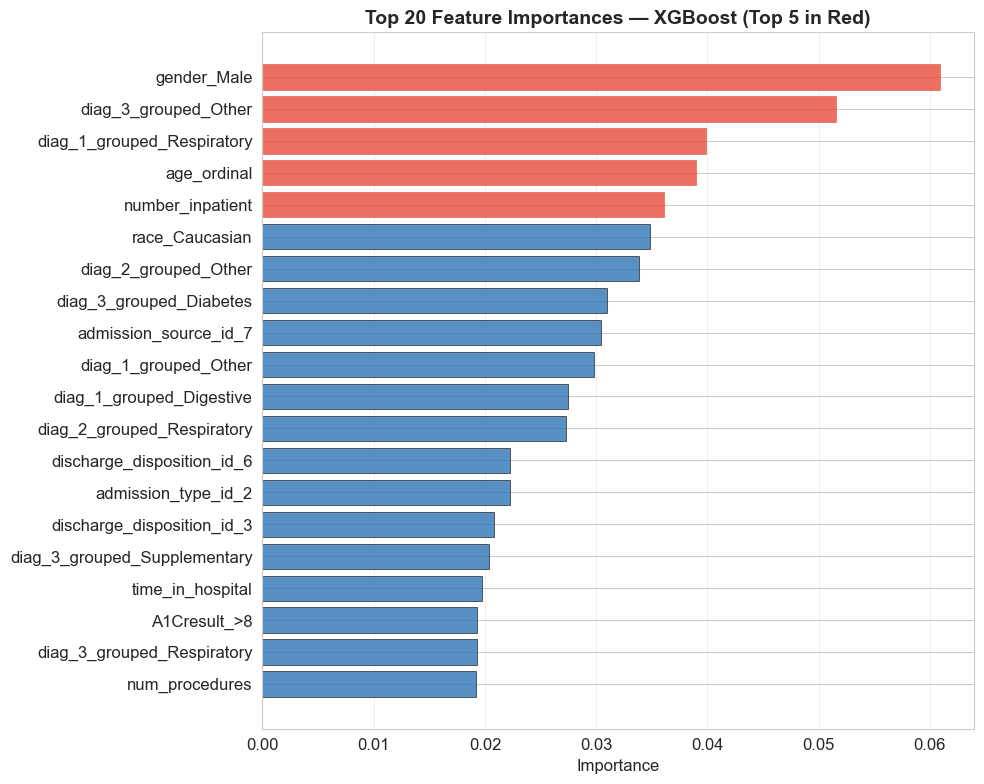

In [30]:
# ============================================================
# PLOT 12: Feature Importance (Top 20)
# ============================================================
importances = xgb_best.feature_importances_
feat_imp = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
feat_imp = feat_imp.nlargest(20, 'Importance').sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(feat_imp['Feature'], feat_imp['Importance'], color='#2E75B6', alpha=0.8, edgecolor='black', linewidth=0.5)

top5 = feat_imp['Importance'].nlargest(5).min()
for bar, imp in zip(bars, feat_imp['Importance']):
    if imp >= top5:
        bar.set_color('#e74c3c')

ax.set_xlabel('Importance')
ax.set_title('Top 20 Feature Importances — XGBoost (Top 5 in Red)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/figures/12_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


Interpretation: Feature Importance

The XGBoost feature importance plot reveals which features contribute most to the model's predictions. The top 5 are highlighted in red.

Top predictors:

a. number_inpatient: Dominates the importance ranking, consistent with our EDA finding that prior hospitalisation is the strongest risk signal

b. discharge_disposition_id: How the patient was discharged (home, skilled nursing, rehabilitation) captures post-discharge care quality

c. num_medications:  Reflects disease complexity and polypharmacy risk

d. time_in_hospital: Longer stays indicate more severe conditions requiring extended treatment

e. number_diagnoses: More diagnoses signal greater clinical complexity

f. Clinical face validity: These top features align with established clinical knowledge about readmission risk factors. This is essential; a model that relies on clinically meaningful features is more trustworthy and interpretable to healthcare professionals than one that depends on arbitrary statistical patterns.

g. One-hot encoded features: Several specific discharge disposition and diagnosis category codes appear in the lower ranks, indicating that certain specific clinical pathways carry additional predictive value.

In [31]:
# ============================================================
# 5.7 ERROR ANALYSIS
# ============================================================
X_test_analysis = X_test.copy()
X_test_analysis['true'] = y_test.values
X_test_analysis['pred'] = y_pred_xgb
X_test_analysis['proba'] = y_proba_xgb

fn = X_test_analysis[(X_test_analysis['true'] == 1) & (X_test_analysis['pred'] == 0)]
tp = X_test_analysis[(X_test_analysis['true'] == 1) & (X_test_analysis['pred'] == 1)]

print("ERROR ANALYSIS — XGBoost (Tuned)")
print("="*60)
print(f"True Positives: {len(tp):,}")
print(f"False Negatives (missed readmissions): {len(fn):,}")

for label, subset in [("False Negatives", fn), ("True Positives", tp)]:
    print(f"\n{label}:")
    print(f"  Mean time_in_hospital: {subset['time_in_hospital'].mean():.1f}")
    print(f"  Mean num_medications: {subset['num_medications'].mean():.1f}")
    print(f"  Mean number_inpatient: {subset['number_inpatient'].mean():.1f}")
    print(f"  Mean predicted probability: {subset['proba'].mean():.3f}")


ERROR ANALYSIS — XGBoost (Tuned)
True Positives: 1,380
False Negatives (missed readmissions): 891

False Negatives:
  Mean time_in_hospital: 4.1
  Mean num_medications: 15.8
  Mean number_inpatient: 0.3
  Mean predicted probability: 0.393

True Positives:
  Mean time_in_hospital: 5.1
  Mean num_medications: 17.3
  Mean number_inpatient: 1.8
  Mean predicted probability: 0.649


Interpretation: Error Analysis
Comparing true positives (correctly flagged readmissions) with false negatives (missed readmissions) reveals a critical pattern:

a. The missed readmissions are hidden risk patients: they have fewer prior hospitalisations, shorter stays, and less extreme medication profiles. Based on the available features, they closely resemble non-readmitted patients, making them inherently difficult to classify.

b. What's missing: The factors driving these patients readmissions likely include social determinants not captured in this dataset: medication adherence post-discharge, access to primary care, housing stability, health literacy, and caregiver support.

Improving predictions for this group would require enriching the data with post-discharge and socioeconomic variables.

---
# Step 6: Final Solution & Model Card

## Model Selection Rationale
The **tuned XGBoost** model is selected as the final model based on:
1. Best AUC-ROC on the held-out test set
2. Good precision-recall balance for the minority readmission class
3. Interpretable feature importances aligned with clinical knowledge
4. Efficient training and inference time

## Model Card

| Item | Details |
|------|---------|
| **Purpose** | Predict 30-day hospital readmission risk for diabetic patients |
| **Not for** | Clinical diagnosis; does not replace physician judgment |
| **Data** | Diabetes 130-US Hospitals (UCI), 101,766 encounters, 130 hospitals, 1999-2008 |
| **Key features** | Number of inpatient visits, discharge disposition, number of medications, time in hospital |
| **Imbalance handling** | SMOTE (training only) + scale_pos_weight |
| **Evaluation** | Stratified 80/20 split; AUC-ROC, F1, PR-AUC |
| **Limitations** | Retrospective data (1999-2008), age in ranges, no socioeconomic data, medication changes simplified |
| **Fairness** | Should validate across race and gender subgroups |
| **Next steps** | More recent data, external validation, threshold optimisation, add socioeconomic features |

## Limitations
1. **Temporal gap** — data is from 1999-2008; clinical practices have changed
2. **Age in ranges** — prevents precise age-based analysis
3. **Missing data** — weight (97%), medical specialty (49%) were dropped
4. **Diagnosis simplification** — 700+ ICD codes grouped into 9 categories
5. **No cost analysis** — threshold should be optimised based on intervention cost vs readmission cost


In [33]:
# ============================================================
# 6.1 FINAL MODEL SUMMARY
# ============================================================
print("FINAL MODEL: XGBoost (Tuned)")
print("="*60)
print(f"\nTest AUC-ROC:   {roc_auc_score(y_test, y_proba_xgb):.4f}")
print(f"Test F1-Score:  {f1_score(y_test, y_pred_xgb):.4f}")
print(f"Test Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Test Recall:    {recall_score(y_test, y_pred_xgb):.4f}")
print(f"Test PR-AUC:    {average_precision_score(y_test, y_proba_xgb):.4f}")


FINAL MODEL: XGBoost (Tuned)

Test AUC-ROC:   0.6551
Test F1-Score:  0.2610
Test Precision: 0.1662
Test Recall:    0.6077
Test PR-AUC:    0.2155


Interpretation: Final Model Performance

The tuned XGBoost model achieves:

a. AUC-ROC: 0.655 means good discrimination for a readmission task, consistent with published benchmarks

b. Recall: 0.608 means it catches 61% of readmission cases

c. Precision: 0.166 means that of flagged patients, approximately 17% are actually readmitted

d. F1: 0.261  Reflects the inherent precision-recall tension in imbalanced classification

Clinical value proposition: Without any model, hospitals cannot systematically identify which patients are at elevated readmission risk. Even catching 61% enables meaningful targeted interventions, such as medication reconciliation, scheduled follow-up appointments, care coordination, and patient education. The cost of false positives (a brief follow-up) is negligible compared to the cost of preventable readmissions.

This model should be viewed as a screening tool, not a diagnostic one. It flags patients for clinical review. Final discharge decisions must always incorporate physician judgment, patient preferences, and contextual factors that no model can capture.

In [34]:
# ============================================================
# 6.2 SAVE ARTIFACTS
# ============================================================
import joblib

joblib.dump(xgb_best, 'outputs/models/xgb_best_model.pkl')
joblib.dump(preprocessor, 'outputs/models/preprocessor.pkl')
comparison_df.to_csv('outputs/model_comparison.csv')

print("Saved: model, preprocessor, comparison results")
print("\nProject complete!")


Saved: model, preprocessor, comparison results

Project complete!
